In [1]:
import os
import pandas as pd
import geopandas as gpd

# -----------------------------
# 0. 경로 설정
# -----------------------------
base_dir = "./data/bnd_dong_11_2025_2Q"
shp_path = os.path.join(base_dir, "bnd_dong_11_2025_2Q.shp")

out_dir = "./cleaned data"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 자치구 코드 매핑
#    (네가 정리한 2025 기준 8자리 코드)
# -----------------------------
gu_code_map = {
    "11010000": "종로구",
    "11020000": "중구",
    "11030000": "용산구",
    "11040000": "성동구",
    "11050000": "광진구",
    "11060000": "동대문구",
    "11070000": "중랑구",
    "11080000": "성북구",
    "11090000": "강북구",
    "11100000": "도봉구",
    "11110000": "노원구",
    "11120000": "은평구",
    "11130000": "서대문구",
    "11140000": "마포구",
    "11150000": "양천구",
    "11160000": "강서구",
    "11170000": "구로구",
    "11180000": "금천구",
    "11190000": "영등포구",
    "11200000": "동작구",
    "11210000": "관악구",
    "11220000": "서초구",
    "11230000": "강남구",
    "11240000": "송파구",
    "11250000": "강동구"
}

# -----------------------------
# 2. shp 불러오기
# -----------------------------
dong = gpd.read_file(shp_path)

print("=== 원본 정보 ===")
print(dong.head())
print("\n컬럼:", dong.columns.tolist())
print("CRS:", dong.crs)
print("행 개수:", len(dong))

# -----------------------------
# 3. 컬럼명/자료형 표준화
# -----------------------------
dong = dong.rename(columns={
    "BASE_DATE": "base_date",
    "ADM_CD": "adm_cd",
    "ADM_NM": "adm_nm"
}).copy()

dong["adm_cd"] = dong["adm_cd"].astype(str).str.zfill(8)
dong["adm_nm"] = dong["adm_nm"].astype(str).str.strip()
dong["base_date"] = pd.to_datetime(
    dong["base_date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

# 기준 shp는 EPSG:5179로 유지
dong = dong.to_crs(epsg=5179)

# -----------------------------
# 4. 자치구 코드/자치구명 생성
#    행정동 8자리 -> 앞 5자리 + 000 = 자치구 8자리
# -----------------------------
dong["gu_cd"] = dong["adm_cd"].str[:5] + "000"
dong["gu_nm"] = dong["gu_cd"].map(gu_code_map)

# 구+동 결합키
dong["adm_key"] = dong["gu_nm"] + "_" + dong["adm_nm"]

# -----------------------------
# 5. 파생 컬럼 생성
# -----------------------------
# 면적
dong["area_m2"] = dong.geometry.area
dong["area_km2"] = dong["area_m2"] / 1_000_000

# 대표점 좌표 (EPSG:5179)
rep_5179 = dong.representative_point()
dong["x_5179"] = rep_5179.x
dong["y_5179"] = rep_5179.y

# 대표점 경위도 (EPSG:4326)
dong_wgs84 = dong.to_crs(epsg=4326)
rep_4326 = dong_wgs84.representative_point()
dong["lon"] = rep_4326.x
dong["lat"] = rep_4326.y

# -----------------------------
# 6. 품질 점검
# -----------------------------
print("\n=== 품질 점검 ===")
print("행정동코드 중복 수:", dong["adm_cd"].duplicated().sum())
print("행정동명 중복 수(정상 가능):", dong["adm_nm"].duplicated().sum())
print("구+동 결합키 중복 수:", dong["adm_key"].duplicated().sum())
print("자치구명 결측 수:", dong["gu_nm"].isna().sum())
print("geometry 결측 수:", dong.geometry.isna().sum())
print("geometry 유효하지 않은 개수:", (~dong.geometry.is_valid).sum())

# 중복 동명 목록
dup_nm = dong[dong["adm_nm"].duplicated(keep=False)].sort_values(["adm_nm", "adm_cd"])

if len(dup_nm) > 0:
    print("\n=== 중복 동명 목록 ===")
    print(dup_nm[["adm_cd", "gu_cd", "gu_nm", "adm_nm", "adm_key"]])
else:
    print("\n중복 동명 없음")

# 자치구명 누락 시 어떤 코드가 문제인지 확인
if dong["gu_nm"].isna().sum() > 0:
    print("\n=== 자치구명 매핑 실패 코드 ===")
    print(dong.loc[dong["gu_nm"].isna(), ["adm_cd", "gu_cd", "adm_nm"]].drop_duplicates())

# -----------------------------
# 7. 필요한 컬럼만 정리
# -----------------------------
dong = dong[[
    "base_date",
    "gu_cd",
    "gu_nm",
    "adm_cd",
    "adm_nm",
    "adm_key",
    "area_m2",
    "area_km2",
    "x_5179",
    "y_5179",
    "lon",
    "lat",
    "geometry"
]].copy()

# -----------------------------
# 8. 저장
# -----------------------------
gpkg_path = os.path.join(out_dir, "adm_dong_2025_base.gpkg")
csv_path = os.path.join(out_dir, "adm_dong_2025_base.csv")
dup_path = os.path.join(out_dir, "adm_dong_2025_dup_names.csv")

dong.to_file(gpkg_path, layer="adm_dong_2025_base", driver="GPKG")
dong.drop(columns="geometry").to_csv(csv_path, index=False, encoding="utf-8-sig")
dup_nm[["adm_cd", "gu_cd", "gu_nm", "adm_nm", "adm_key"]].to_csv(
    dup_path, index=False, encoding="utf-8-sig"
)

print("\n=== 저장 완료 ===")
print("GPKG:", gpkg_path)
print("CSV :", csv_path)
print("중복동명 점검표:", dup_path)

=== 원본 정보 ===
  BASE_DATE    ADM_CD ADM_NM  \
0  20250630  11010530    사직동   
1  20250630  11010540    삼청동   
2  20250630  11010550    부암동   
3  20250630  11010560    평창동   
4  20250630  11010570    무악동   

                                            geometry  
0  POLYGON ((953553.932 1953335.741, 953555.211 1...  
1  POLYGON ((953844.082 1955492.177, 953858.644 1...  
2  POLYGON ((952490.38 1956548.821, 952497.594 19...  
3  POLYGON ((953683.828 1959209.871, 953665.283 1...  
4  POLYGON ((952298.144 1953539.606, 952324.838 1...  

컬럼: ['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']
CRS: EPSG:5179
행 개수: 426

=== 품질 점검 ===
행정동코드 중복 수: 0
행정동명 중복 수(정상 가능): 1
구+동 결합키 중복 수: 0
자치구명 결측 수: 0
geometry 결측 수: 0
geometry 유효하지 않은 개수: 0

=== 중복 동명 목록 ===
       adm_cd     gu_cd gu_nm adm_nm  adm_key
329  11210680  11210000   관악구    신사동  관악구_신사동
358  11230510  11230000   강남구    신사동  강남구_신사동

=== 저장 완료 ===
GPKG: ./cleaned data/adm_dong_2025_base.gpkg
CSV : ./cleaned data/adm_dong_2025_base.csv
중복동명 점검표:

## 2-0: 소방서 안전센터 구조대 위치정보 연도별 파일 합치기

In [2]:
import os
import pandas as pd

# -----------------------------
# 0. 경로 설정
# -----------------------------
raw_dir = "./data/raw data"

fire_files = {
    2020: "소방서 안전센터 구조대 위치정보_2020.xlsx",
    2022: "소방서 안전센터 구조대 위치정보_2022.xlsx",
    2024: "소방서 안전센터 구조대 위치정보_2024.xlsx",
    2025: "소방서 안전센터 구조대 위치정보_2025.xlsx"
}

out_path = os.path.join(raw_dir, "소방서 안전센터 구조대 위치정보.xlsx")

# -----------------------------
# 1. 연도별 파일 읽기 + year 컬럼 추가
# -----------------------------
fire_dfs = []

for year, file_name in fire_files.items():
    path = os.path.join(raw_dir, file_name)

    if not os.path.exists(path):
        raise FileNotFoundError(f"파일이 없습니다: {path}")

    # 시트명이 연도와 같으면 그 시트 사용, 아니면 첫 번째 시트 사용
    xls = pd.ExcelFile(path)
    if str(year) in xls.sheet_names:
        sheet_to_use = str(year)
    else:
        sheet_to_use = xls.sheet_names[0]

    df = pd.read_excel(path, sheet_name=sheet_to_use)

    # 컬럼명 공백 정리
    df.columns = [str(c).strip() for c in df.columns]

    # year 컬럼 추가
    df["year"] = year
    df["source_file"] = file_name
    df["source_sheet"] = sheet_to_use

    fire_dfs.append(df)

# -----------------------------
# 2. 병합
# -----------------------------
fire_merged = pd.concat(fire_dfs, ignore_index=True, sort=False)

print("=== 병합 결과 ===")
print("행 수:", len(fire_merged))
print("컬럼 수:", len(fire_merged.columns))
print("연도별 건수:")
print(fire_merged["year"].value_counts().sort_index())

# -----------------------------
# 3. 저장
# -----------------------------
with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    fire_merged.to_excel(writer, sheet_name="merged", index=False)

print("\n저장 완료:")
print(out_path)

=== 병합 결과 ===
행 수: 718
컬럼 수: 9
연도별 건수:
year
2020    178
2022    180
2024    180
2025    180
Name: count, dtype: int64

저장 완료:
./data/raw data/소방서 안전센터 구조대 위치정보.xlsx


In [3]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd

# -----------------------------
# 0. 경로 설정
# -----------------------------
raw_dir = "./data/raw data"
clean_dir = "./cleaned data"

school_file = "서울시 학교 기본정보_좌표추가.csv"
adm_path = os.path.join(clean_dir, "adm_dong_2025_base.gpkg")

out_point_dir = os.path.join(clean_dir, "infra_points")
out_count_dir = os.path.join(clean_dir, "infra_by_dong")
out_review_dir = os.path.join(clean_dir, "infra_review")

os.makedirs(out_point_dir, exist_ok=True)
os.makedirs(out_count_dir, exist_ok=True)
os.makedirs(out_review_dir, exist_ok=True)

# -----------------------------
# 1. 파일 읽기 함수
# -----------------------------
def read_csv_auto(path):
    for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise ValueError(f"CSV 인코딩을 확인할 수 없습니다: {path}")

# -----------------------------
# 2. 기준 행정동 불러오기
# -----------------------------
adm = gpd.read_file(adm_path, layer="adm_dong_2025_base").to_crs(epsg=5179)
adm = adm[["gu_cd", "gu_nm", "adm_cd", "adm_nm", "adm_key", "geometry"]].copy()

# -----------------------------
# 3. 학교 raw 불러오기
# -----------------------------
school_path = os.path.join(raw_dir, school_file)
school_raw = read_csv_auto(school_path)
school_raw.columns = [str(c).strip() for c in school_raw.columns]

print("=== 학교 raw 정보 ===")
print("행 수:", len(school_raw))
print("고유 학교 수(표준학교코드):", school_raw["표준학교코드"].nunique())

# -----------------------------
# 4. 컬럼 표준화
# -----------------------------
school = school_raw.copy()

school["표준학교코드"] = pd.to_numeric(school["표준학교코드"], errors="coerce").astype("Int64")
school["적재일시"] = pd.to_numeric(school["적재일시"], errors="coerce")
school["위도(Lat)"] = pd.to_numeric(school["위도(Lat)"], errors="coerce")
school["경도(Lng)"] = pd.to_numeric(school["경도(Lng)"], errors="coerce")

text_cols = [
    "학교종류명", "설립구분", "학교명", "영문학교명", "관할조직명",
    "도로명주소", "도로명상세주소", "전화번호", "홈페이지주소",
    "팩스번호", "남녀공학구분명", "고등학교구분명", "고등학교일반실업구분명",
    "특수목적고등학교계열명", "입시전후기구분명", "주야구분명",
    "시도교육청명", "소재지명", "주야과정", "계열명", "학과명"
]

for col in text_cols:
    if col in school.columns:
        school[col] = school[col].astype(str).str.strip()
        school.loc[school[col].isin(["nan", "None", ""]), col] = pd.NA

# -----------------------------
# 5. 1학교 1행 선택 규칙 만들기
#    우선순위:
#    (1) 좌표 있는 행
#    (2) 주요 텍스트 결측이 적은 행
#    (3) 적재일시 최신
# -----------------------------
school["has_coord"] = (
    school["위도(Lat)"].notna() &
    school["경도(Lng)"].notna()
).astype(int)

priority_cols = [
    "학교종류명", "설립구분", "학교명", "도로명주소", "전화번호",
    "남녀공학구분명", "주야구분명", "시도교육청명"
]
existing_priority_cols = [c for c in priority_cols if c in school.columns]

school["nonnull_priority_count"] = school[existing_priority_cols].notna().sum(axis=1)

# 정렬 후 학교코드별 첫 행 선택
school_sorted = school.sort_values(
    by=["표준학교코드", "has_coord", "nonnull_priority_count", "적재일시"],
    ascending=[True, False, False, False]
).copy()

school_dedup = school_sorted.drop_duplicates(subset=["표준학교코드"], keep="first").copy()

print("\n=== 학교 정제 결과 ===")
print("원본 행 수:", len(school))
print("정제 후 행 수:", len(school_dedup))
print("좌표 있는 학교 수:", int((school_dedup["has_coord"] == 1).sum()))
print("좌표 없는 학교 수:", int((school_dedup["has_coord"] == 0).sum()))

# -----------------------------
# 6. 필요한 컬럼만 정리
# -----------------------------
keep_cols = [
    "표준학교코드", "학교종류명", "설립구분", "학교명", "영문학교명", "관할조직명",
    "도로명우편번호", "도로명주소", "도로명상세주소", "전화번호", "홈페이지주소",
    "팩스번호", "남녀공학구분명", "고등학교구분명", "고등학교일반실업구분명",
    "특수목적고등학교계열명", "입시전후기구분명", "주야구분명", "설립일자",
    "개교기념일", "시도교육청코드", "시도교육청명", "소재지명",
    "주야과정", "계열명", "학과명", "적재일시", "위도(Lat)", "경도(Lng)"
]
keep_cols = [c for c in keep_cols if c in school_dedup.columns]
school_dedup = school_dedup[keep_cols + ["has_coord"]].copy()

# 표준 컬럼명 일부 추가
school_dedup = school_dedup.rename(columns={
    "표준학교코드": "source_id",
    "학교명": "name",
    "도로명주소": "address",
    "학교종류명": "school_type",
    "설립구분": "establish_type",
    "위도(Lat)": "lat",
    "경도(Lng)": "lon"
})

school_dedup["dataset_id"] = "school"

# -----------------------------
# 7. 좌표 있는 학교만 GeoDataFrame 생성
# -----------------------------
school_with_coord = school_dedup[
    school_dedup["lon"].notna() & school_dedup["lat"].notna()
].copy()

if len(school_with_coord) > 0:
    school_gdf = gpd.GeoDataFrame(
        school_with_coord,
        geometry=gpd.points_from_xy(school_with_coord["lon"], school_with_coord["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=5179)

    # 표준 좌표
    school_gdf["x_5179"] = school_gdf.geometry.x
    school_gdf["y_5179"] = school_gdf.geometry.y

    school_wgs84 = school_gdf.to_crs(epsg=4326)
    school_gdf["lon"] = school_wgs84.geometry.x
    school_gdf["lat"] = school_wgs84.geometry.y

    # 행정동 공간조인
    school_joined = gpd.sjoin(
        school_gdf,
        adm,
        how="left",
        predicate="within"
    ).drop(columns=["index_right"], errors="ignore")

else:
    # 빈 gdf 생성
    school_joined = gpd.GeoDataFrame(
        school_with_coord,
        geometry=[],
        crs="EPSG:5179"
    )

# -----------------------------
# 8. 행정동별 학교 수 집계
# -----------------------------
if len(school_joined) > 0:
    school_count_by_dong = (
        school_joined[school_joined["adm_cd"].notna()]
        .groupby(["gu_nm", "adm_nm", "adm_cd"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
        .sort_values(["gu_nm", "adm_nm"])
        .reset_index(drop=True)
    )
else:
    school_count_by_dong = pd.DataFrame(columns=["gu_nm", "adm_nm", "adm_cd", "count"])

# -----------------------------
# 9. 저장
# -----------------------------
# 1학교 1행 정제본
dedup_path = os.path.join(out_point_dir, "school_dedup.csv")
school_dedup.to_csv(dedup_path, index=False, encoding="utf-8-sig")

# 좌표 있는 학교 gdf + 행정동 매핑본
if len(school_joined) > 0:
    gpkg_path = os.path.join(out_point_dir, "school_points.gpkg")
    school_joined.to_file(gpkg_path, layer="school", driver="GPKG")

    point_csv_path = os.path.join(out_point_dir, "school_points.csv")
    school_joined.drop(columns="geometry").to_csv(point_csv_path, index=False, encoding="utf-8-sig")
else:
    gpkg_path = None
    point_csv_path = None

# 행정동별 학교 수
count_path = os.path.join(out_count_dir, "school_count_by_dong.csv")
school_count_by_dong.to_csv(count_path, index=False, encoding="utf-8-sig")

# 좌표 없는 학교 점검
no_coord_path = os.path.join(out_review_dir, "school_no_coord.csv")
school_dedup[school_dedup["has_coord"] == 0].to_csv(no_coord_path, index=False, encoding="utf-8-sig")

# 행정동 매핑 실패 점검
if len(school_joined) > 0:
    unmatched_path = os.path.join(out_review_dir, "school_unmatched_points.csv")
    school_joined[school_joined["adm_cd"].isna()].drop(columns="geometry").to_csv(
        unmatched_path, index=False, encoding="utf-8-sig"
    )
else:
    unmatched_path = None

# -----------------------------
# 10. 요약 출력
# -----------------------------
print("\n=== 저장 완료 ===")
print("1학교 1행 정제본:", dedup_path)
print("학교 점 파일:", gpkg_path)
print("학교 점 CSV:", point_csv_path)
print("행정동별 학교 수:", count_path)
print("좌표 없는 학교 점검:", no_coord_path)
print("행정동 매핑 실패 점검:", unmatched_path)

=== 학교 raw 정보 ===
행 수: 13744
고유 학교 수(표준학교코드): 1415

=== 학교 정제 결과 ===
원본 행 수: 13744
정제 후 행 수: 1415
좌표 있는 학교 수: 1415
좌표 없는 학교 수: 0

=== 저장 완료 ===
1학교 1행 정제본: ./cleaned data/infra_points/school_dedup.csv
학교 점 파일: ./cleaned data/infra_points/school_points.gpkg
학교 점 CSV: ./cleaned data/infra_points/school_points.csv
행정동별 학교 수: ./cleaned data/infra_by_dong/school_count_by_dong.csv
좌표 없는 학교 점검: ./cleaned data/infra_review/school_no_coord.csv
행정동 매핑 실패 점검: ./cleaned data/infra_review/school_unmatched_points.csv


In [4]:
import os
import pandas as pd
import numpy as np

# -----------------------------
# 0. 경로 설정
# -----------------------------
raw_dir = "./data/raw data"
clean_dir = "./cleaned data"

ride_path = os.path.join(raw_dir, "서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv")
master_path = os.path.join(clean_dir, "infra_points", "subway_station_master_points.csv")

out_dir = os.path.join(clean_dir, "subway_processed")
review_dir = os.path.join(clean_dir, "infra_review")

os.makedirs(out_dir, exist_ok=True)
os.makedirs(review_dir, exist_ok=True)

# -----------------------------
# 1. 파일 읽기
# -----------------------------
def read_csv_auto(path):
    for enc in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise ValueError(f"CSV 인코딩을 확인할 수 없습니다: {path}")

ride = read_csv_auto(ride_path)
master = read_csv_auto(master_path)

ride.columns = [str(c).strip() for c in ride.columns]
master.columns = [str(c).strip() for c in master.columns]

print("=== 원본 정보 ===")
print("승하차 행 수:", len(ride))
print("역사마스터 행 수:", len(master))

# -----------------------------
# 2. 사용할 컬럼명
# -----------------------------
MONTH_COL = "사용월"
LINE_COL_RIDE = "호선명"
STATION_COL_RIDE = "지하철역"

LINE_COL_MASTER = "line_name"
STATION_COL_MASTER = "name"
STATION_ID_COL = "source_id"

# -----------------------------
# 3. 문자열 표준화 함수
# -----------------------------
def normalize_text(s):
    s = s.astype(str).str.strip()
    s = s.str.replace(r"\s+", "", regex=True)
    s = s.str.replace("·", "ㆍ", regex=False)
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

# 호선 표기 통일
LINE_MAP = {
    "9호선2단계": "9호선(연장)",
    "9호선2~3단계": "9호선(연장)",
    "9호선2,3단계": "9호선(연장)",
    "9호선2단계~3단계": "9호선(연장)",
    "공항철도1호선": "공항철도",
    "공항철도 1호선": "공항철도",
    "경의선": "경의중앙선",
    "중앙선": "경의중앙선",
    "분당선": "수인분당선",
    "수인선": "수인분당선",
    "경인선": "1호선",
    "경부선": "1호선",
    "경원선": "1호선",
    "장항선": "1호선",
    "일산선": "3호선",
    "과천선": "4호선",
    "안산선": "4호선",
    "진접선": "4호선"
}

# 역명 표기 통일
# 여기서 많이 안 맞으면 review 파일 보고 계속 추가하면 됨
STATION_MAP = {
    "총신대입구(이수)": "이수",
    "이수(총신대입구)": "이수",
    "남부터미널(예술의전당)": "남부터미널",
    "어린이대공원(세종대)": "어린이대공원",
    "굽은다리(강동구민회관앞)": "굽은다리",
    "신정(은행정)": "신정",
    "군자(능동)": "군자",
    "광화문(세종문화회관)": "광화문",
    "아차산(어린이대공원후문)": "아차산",
    "한성대입구(삼선교)": "한성대입구",
    "숭실대입구(살피재)": "숭실대입구",
    "몽촌토성(평화의문)": "몽촌토성",
    "새절(신사)": "새절",
    "신촌(경의중앙선)": "신촌",
    "신촌(2호선)": "신촌",
    "서울역(경의중앙선)": "서울역",
    "서울역(1호선)": "서울역",
    "동대문역사문화공원(DDP)": "동대문역사문화공원",
    "마곡나루(서울식물원)": "마곡나루"
}

def normalize_line(s):
    s = normalize_text(s)
    s = s.replace(LINE_MAP)
    return s

def normalize_station(s):
    s = normalize_text(s)
    s = s.replace(STATION_MAP)
    return s

# -----------------------------
# 4. 승하차 데이터 정리
#    사용월/호선명/지하철역 외 숫자 컬럼은 모두 집계 대상
# -----------------------------
ride = ride.copy()
ride[MONTH_COL] = ride[MONTH_COL].astype(str).str.replace(".0", "", regex=False)
ride[LINE_COL_RIDE] = ride[LINE_COL_RIDE].astype(str).str.strip()
ride[STATION_COL_RIDE] = ride[STATION_COL_RIDE].astype(str).str.strip()

ride["line_std"] = normalize_line(ride[LINE_COL_RIDE])
ride["station_std"] = normalize_station(ride[STATION_COL_RIDE])

key_cols = [MONTH_COL, LINE_COL_RIDE, STATION_COL_RIDE, "line_std", "station_std"]

# key 아닌 컬럼 중 숫자형으로 바꿀 수 있는 컬럼만 선별
candidate_cols = [c for c in ride.columns if c not in key_cols]

numeric_cols = []
for col in candidate_cols:
    converted = pd.to_numeric(
        ride[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    )

    # 숫자로 변환된 값이 하나라도 있으면 숫자 컬럼으로 채택
    if converted.notna().sum() > 0:
        ride[col] = converted
        numeric_cols.append(col)

# 사용월이 numeric_cols에 섞였으면 제외
numeric_cols = [c for c in numeric_cols if c != MONTH_COL]

# 사용월이 숫자로 잡히면 제외
numeric_cols = [c for c in numeric_cols if c != MONTH_COL]

print("\n=== 승하차 숫자 집계 컬럼 수 ===")
print(len(numeric_cols))
print(numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")

# 월-호선-역 기준 집계
ride_monthly = (
    ride.groupby(key_cols, as_index=False)[numeric_cols]
    .sum()
)

# 총 승하차량 컬럼
ride_monthly["total_ridership"] = ride_monthly[numeric_cols].sum(axis=1)

print("\n=== 승하차 집계 결과 ===")
print("집계 후 행 수:", len(ride_monthly))

# -----------------------------
# 5. 역사마스터 정리
#    서울 행정동에 매핑된 역만 사용
# -----------------------------
master = master.copy()

# 서울 행정동 안에 매핑된 역만
master = master[master["adm_cd"].notna()].copy()

master[LINE_COL_MASTER] = master[LINE_COL_MASTER].astype(str).str.strip()
master[STATION_COL_MASTER] = master[STATION_COL_MASTER].astype(str).str.strip()

master["line_std"] = normalize_line(master[LINE_COL_MASTER])
master["station_std"] = normalize_station(master[STATION_COL_MASTER])

master_use_cols = [
    STATION_ID_COL, STATION_COL_MASTER, LINE_COL_MASTER,
    "line_std", "station_std",
    "gu_nm", "adm_nm", "adm_cd", "adm_key",
    "lon", "lat", "x_5179", "y_5179"
]
master = master[master_use_cols].copy()

# 같은 표준 호선+역명 조합이 중복되면 점검
master_dup = master[master.duplicated(subset=["line_std", "station_std"], keep=False)].copy()
master_dup_path = os.path.join(review_dir, "subway_station_master_duplicate_keys.csv")
master_dup.to_csv(master_dup_path, index=False, encoding="utf-8-sig")

# 결합용으로는 첫 행만 사용
master_unique = master.drop_duplicates(subset=["line_std", "station_std"], keep="first").copy()
# -----------------------------
# 수동 브릿지: 역사마스터 누락/표기 꼬임 보정
# 서울 행정동 지수용으로 필요한 최소 보정만 추가
# -----------------------------
manual_bridge = pd.DataFrame([
    # 1호선 창동 -> 4호선 창동 좌표/행정동 사용
    {
        "line_std": "1호선",
        "station_std": "창동",
        "source_id": "manual_1ho_changdong",
        "name": "창동",
        "line_name": "1호선",
        "gu_nm": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "gu_nm"
        ].iloc[0],
        "adm_nm": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "adm_nm"
        ].iloc[0],
        "adm_cd": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "adm_cd"
        ].iloc[0],
        "adm_key": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "adm_key"
        ].iloc[0],
        "lon": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "lon"
        ].iloc[0],
        "lat": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "lat"
        ].iloc[0],
        "x_5179": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "x_5179"
        ].iloc[0],
        "y_5179": master_unique.loc[
            (master_unique["station_std"] == "창동") & (master_unique["line_std"] == "4호선"),
            "y_5179"
        ].iloc[0],
    },

    # 수인분당선 복정 -> 8호선 복정 좌표/행정동 사용
    {
        "line_std": "수인분당선",
        "station_std": "복정",
        "source_id": "manual_sbd_bokjeong",
        "name": "복정",
        "line_name": "수인분당선",
        "gu_nm": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "gu_nm"
        ].iloc[0],
        "adm_nm": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "adm_nm"
        ].iloc[0],
        "adm_cd": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "adm_cd"
        ].iloc[0],
        "adm_key": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "adm_key"
        ].iloc[0],
        "lon": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "lon"
        ].iloc[0],
        "lat": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "lat"
        ].iloc[0],
        "x_5179": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "x_5179"
        ].iloc[0],
        "y_5179": master_unique.loc[
            (master_unique["station_std"] == "복정") & (master_unique["line_std"] == "8호선"),
            "y_5179"
        ].iloc[0],
    },

    # 경의중앙선 김포공항 -> 공항철도 김포공항 좌표/행정동 사용
    {
        "line_std": "경의중앙선",
        "station_std": "김포공항",
        "source_id": "manual_gj_kimpogonghang",
        "name": "김포공항",
        "line_name": "경의중앙선",
        "gu_nm": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "gu_nm"
        ].iloc[0],
        "adm_nm": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "adm_nm"
        ].iloc[0],
        "adm_cd": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "adm_cd"
        ].iloc[0],
        "adm_key": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "adm_key"
        ].iloc[0],
        "lon": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "lon"
        ].iloc[0],
        "lat": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "lat"
        ].iloc[0],
        "x_5179": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "x_5179"
        ].iloc[0],
        "y_5179": master_unique.loc[
            (master_unique["station_std"] == "김포공항") & (master_unique["line_std"] == "공항철도"),
            "y_5179"
        ].iloc[0],
    },

    # 2호선 삼성 -> GTX 삼성 좌표/행정동 사용
    {
        "line_std": "2호선",
        "station_std": "삼성",
        "source_id": "manual_2ho_samseong",
        "name": "삼성",
        "line_name": "2호선",
        "gu_nm": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "gu_nm"
        ].iloc[0],
        "adm_nm": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "adm_nm"
        ].iloc[0],
        "adm_cd": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "adm_cd"
        ].iloc[0],
        "adm_key": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "adm_key"
        ].iloc[0],
        "lon": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "lon"
        ].iloc[0],
        "lat": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "lat"
        ].iloc[0],
        "x_5179": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "x_5179"
        ].iloc[0],
        "y_5179": master_unique.loc[
            (master_unique["station_std"] == "삼성"),
            "y_5179"
        ].iloc[0],
    }
])

master_unique = pd.concat([master_unique, manual_bridge], ignore_index=True)
print("\n=== 서울 내 역사마스터 ===")
print("서울 내 역사 수:", len(master))
print("결합용 unique 역사 수:", len(master_unique))
print("중복 key 역사 수:", len(master_dup))

# -----------------------------
# 6. 승하차 + 역사마스터 결합
# -----------------------------
subway_joined = ride_monthly.merge(
    master_unique,
    how="left",
    on=["line_std", "station_std"]
)

print("\n=== 결합 결과 ===")
print("결합 후 행 수:", len(subway_joined))
print("매칭 성공:", int(subway_joined["adm_cd"].notna().sum()))
print("매칭 실패:", int(subway_joined["adm_cd"].isna().sum()))

# 매칭 실패 review 저장
unmatched_path = os.path.join(review_dir, "subway_ridership_unmatched.csv")
subway_joined[subway_joined["adm_cd"].isna()].to_csv(unmatched_path, index=False, encoding="utf-8-sig")

# -----------------------------
# 7. 역 단위 요약
#    월별 자료를 역 단위로 요약
# -----------------------------
matched = subway_joined[subway_joined["adm_cd"].notna()].copy()

station_summary = (
    matched.groupby(
        [STATION_ID_COL, STATION_COL_MASTER, LINE_COL_MASTER, "gu_nm", "adm_nm", "adm_cd"],
        as_index=False
    )
    .agg(
        month_count=(MONTH_COL, "nunique"),
        total_ridership_sum=("total_ridership", "sum"),
        avg_monthly_ridership=("total_ridership", "mean"),
        median_monthly_ridership=("total_ridership", "median")
    )
    .sort_values(["gu_nm", "adm_nm", LINE_COL_MASTER, STATION_COL_MASTER])
    .reset_index(drop=True)
)

# -----------------------------
# 8. 행정동 단위 요약
# -----------------------------
subway_by_dong = (
    station_summary.groupby(["gu_nm", "adm_nm", "adm_cd"], as_index=False)
    .agg(
        station_count=(STATION_ID_COL, "nunique"),
        total_ridership_sum=("total_ridership_sum", "sum"),
        avg_station_monthly_ridership=("avg_monthly_ridership", "mean"),
        median_station_monthly_ridership=("median_monthly_ridership", "median")
    )
    .sort_values(["gu_nm", "adm_nm"])
    .reset_index(drop=True)
)

# -----------------------------
# 9. 저장
# -----------------------------
ride_monthly_path = os.path.join(out_dir, "subway_ridership_monthly_agg.csv")
joined_path = os.path.join(out_dir, "subway_ridership_joined.csv")
station_summary_path = os.path.join(out_dir, "subway_station_summary.csv")
by_dong_path = os.path.join(out_dir, "subway_metrics_by_dong.csv")

ride_monthly.to_csv(ride_monthly_path, index=False, encoding="utf-8-sig")
subway_joined.to_csv(joined_path, index=False, encoding="utf-8-sig")
station_summary.to_csv(station_summary_path, index=False, encoding="utf-8-sig")
subway_by_dong.to_csv(by_dong_path, index=False, encoding="utf-8-sig")

# -----------------------------
# 10. 요약 출력
# -----------------------------
print("\n=== 저장 완료 ===")
print("월별 집계:", ride_monthly_path)
print("결합 결과:", joined_path)
print("역 단위 요약:", station_summary_path)
print("행정동별 지하철 지표:", by_dong_path)
print("매칭 실패 점검:", unmatched_path)
print("역사마스터 중복 key 점검:", master_dup_path)

=== 원본 정보 ===
승하차 행 수: 81111
역사마스터 행 수: 783

=== 승하차 숫자 집계 컬럼 수 ===
49
['04시-05시 승차인원', '04시-05시 하차인원', '05시-06시 승차인원', '05시-06시 하차인원', '06시-07시 승차인원', '06시-07시 하차인원', '07시-08시 승차인원', '07시-08시 하차인원', '08시-09시 승차인원', '08시-09시 하차인원'] ...

=== 승하차 집계 결과 ===
집계 후 행 수: 80407

=== 서울 내 역사마스터 ===
서울 내 역사 수: 401
결합용 unique 역사 수: 403
중복 key 역사 수: 4

=== 결합 결과 ===
결합 후 행 수: 80407
매칭 성공: 49333
매칭 실패: 31074

=== 저장 완료 ===
월별 집계: ./cleaned data/subway_processed/subway_ridership_monthly_agg.csv
결합 결과: ./cleaned data/subway_processed/subway_ridership_joined.csv
역 단위 요약: ./cleaned data/subway_processed/subway_station_summary.csv
행정동별 지하철 지표: ./cleaned data/subway_processed/subway_metrics_by_dong.csv
매칭 실패 점검: ./cleaned data/infra_review/subway_ridership_unmatched.csv
역사마스터 중복 key 점검: ./cleaned data/infra_review/subway_station_master_duplicate_keys.csv


In [5]:
import pandas as pd

unmatched = pd.read_csv(
    "./cleaned data/infra_review/subway_ridership_unmatched.csv",
    encoding="utf-8-sig"
)

print("매칭 실패 행 수:", len(unmatched))
print("매칭 실패 고유 호선-역 조합 수:", unmatched[["line_std", "station_std"]].drop_duplicates().shape[0])

print("\n=== 매칭 실패 상위 30개 호선-역 조합 ===")
top_unmatched = (
    unmatched.groupby(["line_std", "station_std"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(30)
)
print(top_unmatched)

print("\n=== 매칭 실패 상위 역명만 보기 ===")
top_station_only = (
    unmatched.groupby(["station_std"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(30)
)
print(top_station_only)

매칭 실패 행 수: 31074
매칭 실패 고유 호선-역 조합 수: 296

=== 매칭 실패 상위 30개 호선-역 조합 ===
    line_std station_std  size
96       3호선          지축   234
0        1호선          가능   135
209    경의중앙선          오빈   135
196    경의중앙선          능곡   135
197    경의중앙선          덕소   135
198    경의중앙선          도농   135
199    경의중앙선          도심   135
200    경의중앙선          문산   135
201    경의중앙선          백마   135
203    경의중앙선          신원   135
204    경의중앙선          아신   135
206    경의중앙선          양수   135
207    경의중앙선          양정   135
208    경의중앙선          양평   135
210    경의중앙선          용문   135
194    경의중앙선          금릉   135
211    경의중앙선         운길산   135
212    경의중앙선          운정   135
214    경의중앙선          원덕   135
215    경의중앙선          월롱   135
216    경의중앙선          일산   135
219    경의중앙선          탄현   135
220    경의중앙선          파주   135
221    경의중앙선          팔당   135
222    경의중앙선          풍산   135
224    경의중앙선          행신   135
195    경의중앙선          금촌   135
193    경의중앙선          국수   135
227      경춘선          갈매   135

In [6]:
import pandas as pd

unmatched = pd.read_csv(
    "./cleaned data/infra_review/subway_ridership_unmatched.csv",
    encoding="utf-8-sig"
)

master = pd.read_csv(
    "./cleaned data/infra_points/subway_station_master_points.csv",
    encoding="utf-8-sig"
)

# 서울 내 역사마스터에 존재하는 역명 목록
master_station_names = set(master["name"].astype(str).str.strip())
master_station_names_std = set(master["name"].astype(str).str.strip().str.replace(r"\s+", "", regex=True))

# unmatched에서 서울 역명과 겹치는 것만 보기
cand = unmatched[
    unmatched["station_std"].astype(str).isin(master_station_names_std)
].copy()

print("서울 역사마스터 역명과 겹치는 실패 행 수:", len(cand))
print("서울 역사마스터 역명과 겹치는 고유 조합 수:", cand[["line_std", "station_std"]].drop_duplicates().shape[0])

print("\n=== 서울 역명인데 실패한 상위 50개 ===")
print(
    cand.groupby(["line_std", "station_std"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(50)
)

서울 역사마스터 역명과 겹치는 실패 행 수: 29511
서울 역사마스터 역명과 겹치는 고유 조합 수: 237

=== 서울 역명인데 실패한 상위 50개 ===
    line_std station_std  size
75       3호선          지축   234
0        1호선          가능   135
147    경의중앙선          아신   135
150    경의중앙선          양정   135
151    경의중앙선          양평   135
152    경의중앙선          오빈   135
153    경의중앙선          용문   135
154    경의중앙선         운길산   135
155    경의중앙선          운정   135
157    경의중앙선          원덕   135
158    경의중앙선          월롱   135
159    경의중앙선          일산   135
162    경의중앙선          탄현   135
163    경의중앙선          파주   135
164    경의중앙선          팔당   135
165    경의중앙선          풍산   135
166    경의중앙선          행신   135
168      경춘선          가평   135
169      경춘선          갈매   135
170      경춘선          강촌   135
171      경춘선         굴봉산   135
172      경춘선          금곡   135
173      경춘선         김유정   135
149    경의중앙선          양수   135
146    경의중앙선          신원   135
175      경춘선         대성리   135
145    경의중앙선          백마   135
101      7호선       광명사거리   135
110      7호선

In [7]:
import pandas as pd

unmatched = pd.read_csv(
    "./cleaned data/infra_review/subway_ridership_unmatched.csv",
    encoding="utf-8-sig"
)

master = pd.read_csv(
    "./cleaned data/infra_points/subway_station_master_points.csv",
    encoding="utf-8-sig"
)

# 서울 내 역사만 필터링
master_seoul = master[master["adm_cd"].notna()].copy()

# 공백 제거 표준화
master_seoul["station_std_only"] = (
    master_seoul["name"].astype(str)
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
)

cand = unmatched[
    unmatched["station_std"].astype(str).isin(set(master_seoul["station_std_only"]))
].copy()

print("서울 내 역사명과 겹치는 실패 행 수:", len(cand))
print("서울 내 역사명과 겹치는 고유 조합 수:", cand[["line_std", "station_std"]].drop_duplicates().shape[0])

print("\n=== 서울 내 역명인데 실패한 상위 50개 ===")
print(
    cand.groupby(["line_std", "station_std"], as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(50)
)

서울 내 역사명과 겹치는 실패 행 수: 135
서울 내 역사명과 겹치는 고유 조합 수: 1

=== 서울 내 역명인데 실패한 상위 50개 ===
  line_std station_std  size
0    경의중앙선          양평   135


In [8]:
import os
import pandas as pd
import numpy as np

# -----------------------------
# 0. 경로 설정
# -----------------------------
clean_dir = "./cleaned data"
by_dong_dir = os.path.join(clean_dir, "infra_by_dong")
subway_dir = os.path.join(clean_dir, "subway_processed")

adm_path = os.path.join(clean_dir, "adm_dong_2025_base.csv")

out_dir = os.path.join(clean_dir, "infra_master")
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 코드 정규화 함수
# -----------------------------
def normalize_adm_cd(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

# -----------------------------
# 2. 기준 행정동 불러오기
# -----------------------------
adm = pd.read_csv(adm_path, encoding="utf-8-sig")

adm["adm_cd"] = normalize_adm_cd(adm["adm_cd"])
adm["gu_cd"] = normalize_adm_cd(adm["gu_cd"])

base = adm[[
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "adm_key",
    "area_m2", "area_km2", "x_5179", "y_5179", "lon", "lat"
]].copy()

print("=== 기준 행정동 ===")
print("행 수:", len(base))
print("행정동코드 고유값 수:", base["adm_cd"].nunique())

# -----------------------------
# 3. count 파일 읽기 함수
# -----------------------------
def read_count_file(path, value_name):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df["adm_cd"] = normalize_adm_cd(df["adm_cd"])

    if "count" in df.columns:
        df = df.rename(columns={"count": value_name})
    elif value_name not in df.columns:
        raise ValueError(f"{path} 에서 '{value_name}' 컬럼을 찾을 수 없습니다.")

    return df[["adm_cd", value_name]].copy()

# -----------------------------
# 4. 파일별 데이터 불러오기
# -----------------------------
bus = read_count_file(
    os.path.join(by_dong_dir, "bus_stop_count_by_dong.csv"),
    "bus_stop_count"
)

hospital = read_count_file(
    os.path.join(by_dong_dir, "hospital_count_by_dong.csv"),
    "hospital_count"
)

library = read_count_file(
    os.path.join(by_dong_dir, "library_count_by_dong.csv"),
    "library_count"
)

park = read_count_file(
    os.path.join(by_dong_dir, "park_count_by_dong.csv"),
    "park_count"
)

fire_station = read_count_file(
    os.path.join(by_dong_dir, "fire_station_count_by_dong.csv"),
    "fire_station_count"
)

school = read_count_file(
    os.path.join(by_dong_dir, "school_count_by_dong.csv"),
    "school_count"
)

subway = pd.read_csv(
    os.path.join(subway_dir, "subway_metrics_by_dong.csv"),
    encoding="utf-8-sig"
)

subway["adm_cd"] = normalize_adm_cd(subway["adm_cd"])

subway = subway[[
    "adm_cd",
    "station_count",
    "total_ridership_sum",
    "avg_station_monthly_ridership",
    "median_station_monthly_ridership"
]].copy()

subway = subway.rename(columns={
    "station_count": "subway_station_count",
    "total_ridership_sum": "subway_total_ridership_sum",
    "avg_station_monthly_ridership": "subway_avg_station_monthly_ridership",
    "median_station_monthly_ridership": "subway_median_station_monthly_ridership"
})

# -----------------------------
# 5. 기준 행정동에 순차 merge
# -----------------------------
infra = base.copy()

for df in [bus, hospital, library, park, fire_station, school, subway]:
    infra = infra.merge(df, how="left", on="adm_cd")

# -----------------------------
# 6. 결측 채우기
#    count/지표형 변수는 없는 동이면 0으로 처리
# -----------------------------
feature_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count",
    "subway_total_ridership_sum",
    "subway_avg_station_monthly_ridership",
    "subway_median_station_monthly_ridership"
]

for col in feature_cols:
    if col in infra.columns:
        infra[col] = infra[col].fillna(0)

# -----------------------------
# 7. 밀도/보정 변수 생성
#    면적 대비 밀도 (km²당)
# -----------------------------
count_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    infra[density_col] = np.where(
        infra["area_km2"] > 0,
        infra[col] / infra["area_km2"],
        np.nan
    )

infra["subway_total_ridership_density"] = np.where(
    infra["area_km2"] > 0,
    infra["subway_total_ridership_sum"] / infra["area_km2"],
    np.nan
)

# -----------------------------
# 8. 요약 변수 생성
# -----------------------------
infra["infra_count_sum"] = infra[count_cols].sum(axis=1)

infra["infra_density_sum"] = infra[[
    "bus_stop_density",
    "hospital_density",
    "library_density",
    "park_density",
    "fire_station_density",
    "school_density",
    "subway_station_density"
]].sum(axis=1)

# -----------------------------
# 9. 품질 점검
# -----------------------------
print("\n=== 통합 결과 점검 ===")
print("최종 행 수:", len(infra))
print("행정동코드 고유값 수:", infra["adm_cd"].nunique())
print("중복 행정동코드 수:", infra["adm_cd"].duplicated().sum())

print("\n=== 결측 점검 ===")
print(infra[feature_cols].isna().sum())

print("\n=== 지하철 값이 있는 행정동 수 ===")
print("subway_station_count > 0 :", int((infra["subway_station_count"] > 0).sum()))
print("subway_total_ridership_sum > 0 :", int((infra["subway_total_ridership_sum"] > 0).sum()))

print("\n=== 주요 변수 기초통계 ===")
print(
    infra[
        [
            "bus_stop_count",
            "hospital_count",
            "library_count",
            "park_count",
            "fire_station_count",
            "school_count",
            "subway_station_count",
            "subway_total_ridership_sum"
        ]
    ].describe()
)

# -----------------------------
# 10. 저장
# -----------------------------
raw_out_path = os.path.join(out_dir, "infra_master_by_dong_raw.csv")
feature_out_path = os.path.join(out_dir, "infra_master_by_dong_features.csv")

raw_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "adm_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "subway_station_count",
    "subway_total_ridership_sum",
    "subway_avg_station_monthly_ridership",
    "subway_median_station_monthly_ridership"
]
infra[raw_cols].to_csv(raw_out_path, index=False, encoding="utf-8-sig")

feature_cols_full = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "adm_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "subway_station_count",
    "subway_total_ridership_sum",
    "subway_avg_station_monthly_ridership",
    "subway_median_station_monthly_ridership",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "fire_station_density", "school_density", "subway_station_density",
    "subway_total_ridership_density",
    "infra_count_sum", "infra_density_sum"
]
infra[feature_cols_full].to_csv(feature_out_path, index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("raw 마스터:", raw_out_path)
print("feature 마스터:", feature_out_path)

=== 기준 행정동 ===
행 수: 426
행정동코드 고유값 수: 426

=== 통합 결과 점검 ===
최종 행 수: 426
행정동코드 고유값 수: 426
중복 행정동코드 수: 0

=== 결측 점검 ===
bus_stop_count                             0
hospital_count                             0
library_count                              0
park_count                                 0
fire_station_count                         0
school_count                               0
subway_station_count                       0
subway_total_ridership_sum                 0
subway_avg_station_monthly_ridership       0
subway_median_station_monthly_ridership    0
dtype: int64

=== 지하철 값이 있는 행정동 수 ===
subway_station_count > 0 : 230
subway_total_ridership_sum > 0 : 230

=== 주요 변수 기초통계 ===
       bus_stop_count  hospital_count  library_count  park_count  \
count      426.000000      426.000000     426.000000  426.000000   
mean        26.377934       52.204225       0.504695    0.302817   
std         14.844460       60.108162       0.662421    0.561378   
min          1.000000        1.0000

## 7단계 a: 1차 인프라 지수

In [9]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# 0. 경로 설정
# -----------------------------
clean_dir = "./cleaned data"
master_dir = os.path.join(clean_dir, "infra_master")
out_dir = os.path.join(clean_dir, "infra_index")
os.makedirs(out_dir, exist_ok=True)

feature_path = os.path.join(master_dir, "infra_master_by_dong_features.csv")

# -----------------------------
# 1. 데이터 불러오기
# -----------------------------
df = pd.read_csv(feature_path, encoding="utf-8-sig")

df["adm_cd"] = pd.to_numeric(df["adm_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)
df["gu_cd"] = pd.to_numeric(df["gu_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)

print("=== 원본 데이터 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# -----------------------------
# 2. 스케일링 함수
# -----------------------------
def log_cap_minmax(series, cap_q=0.95):
    s = pd.to_numeric(series, errors="coerce").fillna(0).copy()
    s = s.clip(lower=0)

    s_log = np.log1p(s)
    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    scaled = (s_cap - min_val) / (max_val - min_val) * 100
    return scaled

# -----------------------------
# 3. 사용할 변수 확인
# -----------------------------
use_vars = [
    "bus_stop_density",
    "hospital_density",
    "school_density",
    "library_density",
    "park_density",
    "fire_station_density",
    "subway_station_density",
    "subway_total_ridership_density"
]

print("\n=== 사용할 변수 결측 확인 ===")
print(df[use_vars].isna().sum())

# -----------------------------
# 4. 변수별 스코어 생성 (0~100)
# -----------------------------
df["score_bus"] = log_cap_minmax(df["bus_stop_density"])
df["score_hospital"] = log_cap_minmax(df["hospital_density"])
df["score_school"] = log_cap_minmax(df["school_density"])
df["score_library"] = log_cap_minmax(df["library_density"])
df["score_park"] = log_cap_minmax(df["park_density"])
df["score_fire"] = log_cap_minmax(df["fire_station_density"])
df["score_subway_station"] = log_cap_minmax(df["subway_station_density"])
df["score_subway_ridership"] = log_cap_minmax(df["subway_total_ridership_density"])

# -----------------------------
# 5. 하위지수 계산
# -----------------------------
df["transport_index"] = (
    0.50 * df["score_bus"] +
    0.25 * df["score_subway_station"] +
    0.25 * df["score_subway_ridership"]
)

df["medical_living_index"] = df["score_hospital"]
df["education_index"] = df["score_school"]

df["culture_green_index"] = (
    0.50 * df["score_library"] +
    0.50 * df["score_park"]
)

df["safety_index"] = df["score_fire"]

# -----------------------------
# 6. 최종 인프라 지수 계산
# -----------------------------
df["infra_index_v1"] = (
    0.20 * df["transport_index"] +
    0.20 * df["medical_living_index"] +
    0.20 * df["education_index"] +
    0.20 * df["culture_green_index"] +
    0.20 * df["safety_index"]
)

df["infra_index_v1"] = df["infra_index_v1"].clip(0, 100)

# -----------------------------
# 7. 정수형 컬럼 추가
#    팀 합의 반영: 스코어/하위지수/최종지수 모두 반올림 정수
# -----------------------------
score_cols = [
    "score_bus", "score_hospital", "score_school", "score_library",
    "score_park", "score_fire", "score_subway_station", "score_subway_ridership"
]

subindex_cols = [
    "transport_index", "medical_living_index", "education_index",
    "culture_green_index", "safety_index"
]

final_cols = ["infra_index_v1"]

for col in score_cols + subindex_cols + final_cols:
    df[col] = df[col].clip(0, 100)
    df[f"{col}_int"] = df[col].round().astype(int)

# 최종 제출용 지수 컬럼명 유지
df["infra_index_v1_int"] = df["infra_index_v1"].round().astype(int)

# -----------------------------
# 8. 참고용 순위 생성
# -----------------------------
df["infra_rank_v1"] = df["infra_index_v1"].rank(method="min", ascending=False).astype(int)

# -----------------------------
# 9. 품질 점검
# -----------------------------
print("\n=== 하위지수 기초통계 ===")
print(df[[
    "transport_index",
    "medical_living_index",
    "education_index",
    "culture_green_index",
    "safety_index",
    "infra_index_v1"
]].describe())

print("\n=== 최종 지수 상위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v1_int", "infra_rank_v1"]]
    .sort_values("infra_index_v1_int", ascending=False)
    .head(10)
)

print("\n=== 최종 지수 하위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v1_int", "infra_rank_v1"]]
    .sort_values("infra_index_v1_int", ascending=True)
    .head(10)
)

# -----------------------------
# 10. 저장용 파일 생성
# -----------------------------
detail_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "adm_key",
    "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "subway_station_count",
    "subway_total_ridership_sum",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "fire_station_density", "school_density", "subway_station_density",
    "subway_total_ridership_density",

    # 실수형 score
    "score_bus", "score_hospital", "score_school", "score_library",
    "score_park", "score_fire", "score_subway_station", "score_subway_ridership",

    # 정수형 score
    "score_bus_int", "score_hospital_int", "score_school_int", "score_library_int",
    "score_park_int", "score_fire_int", "score_subway_station_int", "score_subway_ridership_int",

    # 실수형 하위지수
    "transport_index", "medical_living_index", "education_index",
    "culture_green_index", "safety_index",

    # 정수형 하위지수
    "transport_index_int", "medical_living_index_int", "education_index_int",
    "culture_green_index_int", "safety_index_int",

    # 최종지수
    "infra_index_v1", "infra_index_v1_int", "infra_rank_v1"
]

detail_path = os.path.join(out_dir, "infra_index_v1_detail.csv")
df[detail_cols].to_csv(detail_path, index=False, encoding="utf-8-sig")

# 제출용 파일
submit = df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v1_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_v1_int": "지수"
})
submit_path = os.path.join(out_dir, "infra_index_v1_submit.csv")
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")

# 스코어 맵 파일
score_summary = pd.DataFrame({
    "variable": [
        "bus_stop_density",
        "hospital_density",
        "school_density",
        "library_density",
        "park_density",
        "fire_station_density",
        "subway_station_density",
        "subway_total_ridership_density"
    ],
    "score_col_float": [
        "score_bus",
        "score_hospital",
        "score_school",
        "score_library",
        "score_park",
        "score_fire",
        "score_subway_station",
        "score_subway_ridership"
    ],
    "score_col_int": [
        "score_bus_int",
        "score_hospital_int",
        "score_school_int",
        "score_library_int",
        "score_park_int",
        "score_fire_int",
        "score_subway_station_int",
        "score_subway_ridership_int"
    ]
})
summary_path = os.path.join(out_dir, "infra_index_v1_score_map.csv")
score_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)
print("스코어 맵:", summary_path)

=== 원본 데이터 ===
행 수: 426
행정동코드 고유값 수: 426

=== 사용할 변수 결측 확인 ===
bus_stop_density                  0
hospital_density                  0
school_density                    0
library_density                   0
park_density                      0
fire_station_density              0
subway_station_density            0
subway_total_ridership_density    0
dtype: int64

=== 하위지수 기초통계 ===
       transport_index  medical_living_index  education_index  \
count       426.000000            426.000000       426.000000   
mean         56.034816             70.668416        56.779028   
std          22.592136             19.169397        26.482514   
min           0.000000              0.000000         0.000000   
25%          36.924792             59.904330        41.759424   
50%          50.044838             72.753609        58.945019   
75%          76.782535             84.447215        75.121224   
max         100.000000            100.000000       100.000000   

       culture_green_index  saf

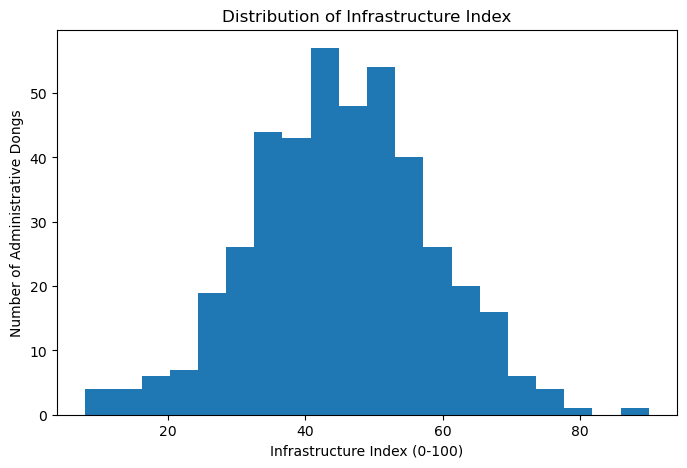

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./cleaned data/infra_index/infra_index_v1_detail.csv", encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.hist(df["infra_index_v1_int"], bins=20)
plt.xlabel("Infrastructure Index (0-100)")
plt.ylabel("Number of Administrative Dongs")
plt.title("Distribution of Infrastructure Index")
plt.show()

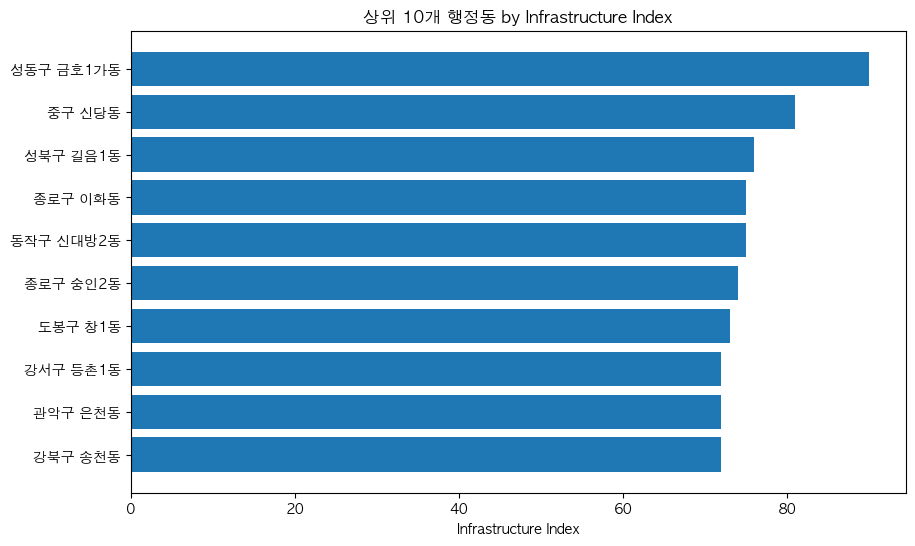

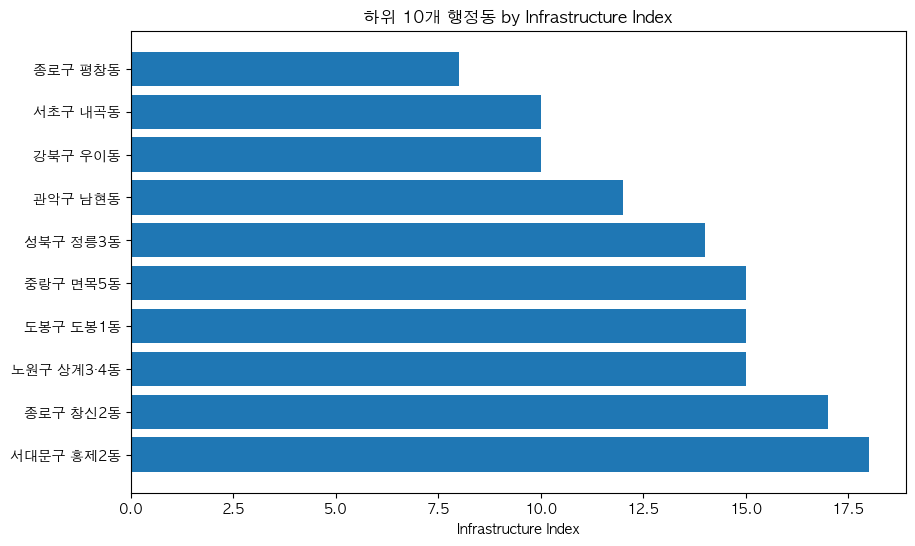

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("./cleaned data/infra_index/infra_index_v1_detail.csv", encoding="utf-8-sig")

top10 = df.sort_values("infra_index_v1_int", ascending=False).head(10).copy()
top10["label"] = top10["gu_nm"] + " " + top10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(top10["label"], top10["infra_index_v1_int"])
plt.gca().invert_yaxis()
plt.xlabel("Infrastructure Index")
plt.title("상위 10개 행정동 by Infrastructure Index")
plt.show()

bottom10 = df.sort_values("infra_index_v1_int", ascending=True).head(10).copy()
bottom10["label"] = bottom10["gu_nm"] + " " + bottom10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(bottom10["label"], bottom10["infra_index_v1_int"])
plt.gca().invert_yaxis()
plt.xlabel("Infrastructure Index")
plt.title("하위 10개 행정동 by Infrastructure Index")
plt.show()

<Figure size 1000x1000 with 0 Axes>

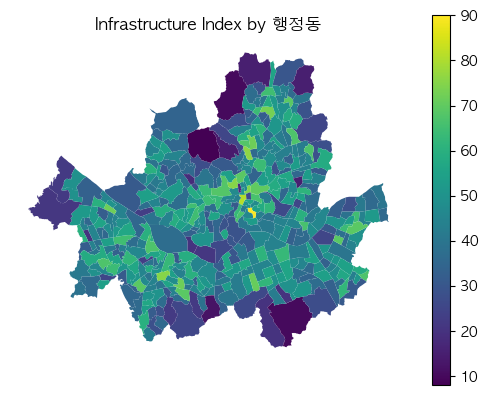

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

shp = gpd.read_file("./cleaned data/adm_dong_2025_base.gpkg", layer="adm_dong_2025_base")
idx = pd.read_csv("./cleaned data/infra_index/infra_index_v1_detail.csv", encoding="utf-8-sig")

shp["adm_cd"] = pd.to_numeric(shp["adm_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)
idx["adm_cd"] = pd.to_numeric(idx["adm_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)

gdf = shp.merge(idx[["adm_cd", "infra_index_v1_int"]], on="adm_cd", how="left")

plt.figure(figsize=(10, 10))
gdf.plot(column="infra_index_v1_int", legend=True)
plt.title("Infrastructure Index by 행정동")
plt.axis("off")
plt.show()

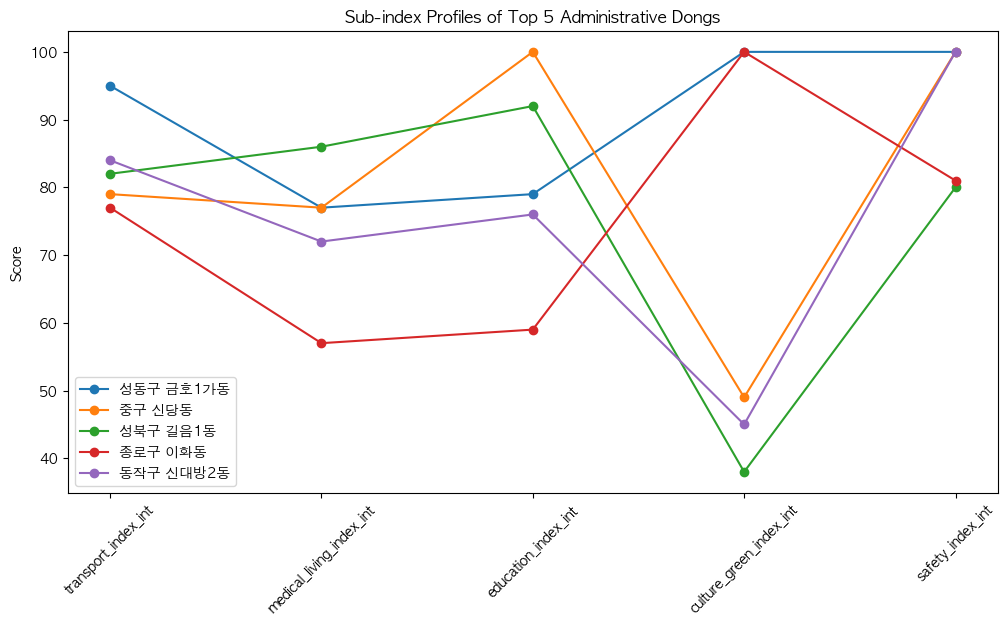

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./cleaned data/infra_index/infra_index_v1_detail.csv", encoding="utf-8-sig")

top5 = df.sort_values("infra_index_v1_int", ascending=False).head(5).copy()
top5["label"] = top5["gu_nm"] + " " + top5["adm_nm"]

sub_cols = [
    "transport_index_int",
    "medical_living_index_int",
    "education_index_int",
    "culture_green_index_int",
    "safety_index_int"
]

plot_df = top5[["label"] + sub_cols].set_index("label").T

plt.figure(figsize=(12, 6))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)

plt.title("Sub-index Profiles of Top 5 Administrative Dongs")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [14]:
import os
import re
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =============================
# 0. 경로 설정
# =============================
clean_dir = "./cleaned data"
master_dir = os.path.join(clean_dir, "infra_master")
base_path = os.path.join(clean_dir, "adm_dong_2025_base.gpkg")

raw_master_path = os.path.join(master_dir, "infra_master_by_dong_raw.csv")
compare_path = "./data/raw data/서울시 행정동별 상권발달 개별지수.csv"

out_dir = os.path.join(clean_dir, "infra_final")
os.makedirs(out_dir, exist_ok=True)

# =============================
# 1. 한글 폰트 설정
# =============================
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

# =============================
# 2. 공통 함수
# =============================
def normalize_adm_cd(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA

    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    # 표준화 규칙
    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    # 상계3,4동 / 상계3_4동 / 상계3·4동 → 상계3·4동
    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

def log_cap_minmax(series, cap_q=0.95):
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)
    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    return (s_cap - min_val) / (max_val - min_val) * 100

def top_bottom_overlap(df, score_col_a, score_col_b, top_ratio=0.2):
    n = len(df)
    k = max(1, math.ceil(n * top_ratio))

    top_a = set(df.sort_values(score_col_a, ascending=False).head(k)["merge_key"])
    top_b = set(df.sort_values(score_col_b, ascending=False).head(k)["merge_key"])

    bottom_a = set(df.sort_values(score_col_a, ascending=True).head(k)["merge_key"])
    bottom_b = set(df.sort_values(score_col_b, ascending=True).head(k)["merge_key"])

    top_overlap = len(top_a & top_b) / k
    bottom_overlap = len(bottom_a & bottom_b) / k

    return k, top_overlap, bottom_overlap

# =============================
# 3. 기준 행정동 로드 + 표준화 코드맵 생성
# =============================
base_gdf = gpd.read_file(base_path, layer="adm_dong_2025_base")
base_df = base_gdf.drop(columns="geometry").copy()

base_df["adm_cd"] = normalize_adm_cd(base_df["adm_cd"])
base_df["gu_cd"] = normalize_adm_cd(base_df["gu_cd"])
base_df["gu_nm"] = clean_text(base_df["gu_nm"])
base_df["adm_nm"] = clean_text(base_df["adm_nm"])
base_df["adm_nm_std"] = base_df["adm_nm"].apply(standardize_dong_name)
base_df["merge_key"] = base_df["gu_nm"] + "_" + base_df["adm_nm_std"]

# 같은 자치구 내 같은 이름 동 기준 target code
target_code_map = base_df[[
    "merge_key", "gu_nm", "adm_nm_std", "adm_cd", "gu_cd"
]].drop_duplicates().copy()

# =============================
# 4. 현재 인프라 마스터 로드 + 이름 표준화 + 같은 이름 동 통합
# =============================
raw = pd.read_csv(raw_master_path, encoding="utf-8-sig")

raw["adm_cd"] = normalize_adm_cd(raw["adm_cd"])
raw["gu_cd"] = normalize_adm_cd(raw["gu_cd"])
raw["gu_nm"] = clean_text(raw["gu_nm"])
raw["adm_nm"] = clean_text(raw["adm_nm"])
raw["adm_nm_std"] = raw["adm_nm"].apply(standardize_dong_name)
raw["merge_key"] = raw["gu_nm"] + "_" + raw["adm_nm_std"]

# 같은 자치구 내 같은 표준화 동명 기준으로 통합
agg_dict = {
    "gu_cd": "first",
    "area_m2": "sum",
    "area_km2": "sum",
    "bus_stop_count": "sum",
    "hospital_count": "sum",
    "library_count": "sum",
    "park_count": "sum",
    "fire_station_count": "sum",
    "school_count": "sum",
    "subway_station_count": "sum",
    "subway_total_ridership_sum": "sum"
}

current = (
    raw.groupby(["gu_nm", "adm_nm_std", "merge_key"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"adm_nm_std": "adm_nm"})
)

# target 2025 코드 붙이기
current = current.merge(
    target_code_map[["merge_key", "adm_cd"]],
    how="left",
    on="merge_key"
)

# 혹시 target code 누락 점검
current["adm_cd"] = clean_text(current["adm_cd"])
print("=== 이름 표준화 후 현재 데이터 ===")
print("행 수:", len(current))
print("코드 누락 수:", current["adm_cd"].isna().sum())

# =============================
# 5. density 재계산
# =============================
count_cols = [
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    current[density_col] = np.where(
        current["area_km2"] > 0,
        current[col] / current["area_km2"],
        0
    )

current["subway_total_ridership_density"] = np.where(
    current["area_km2"] > 0,
    current["subway_total_ridership_sum"] / current["area_km2"],
    0
)

# =============================
# 6. 최종 인프라 지수 재산출
# =============================
# 변수별 스코어
current["score_bus"] = log_cap_minmax(current["bus_stop_density"])
current["score_hospital"] = log_cap_minmax(current["hospital_density"])
current["score_school"] = log_cap_minmax(current["school_density"])
current["score_library"] = log_cap_minmax(current["library_density"])
current["score_park"] = log_cap_minmax(current["park_density"])
current["score_fire"] = log_cap_minmax(current["fire_station_density"])
current["score_subway_station"] = log_cap_minmax(current["subway_station_density"])
current["score_subway_ridership"] = log_cap_minmax(current["subway_total_ridership_density"])

# 하위지수
current["transport_index"] = (
    0.50 * current["score_bus"] +
    0.25 * current["score_subway_station"] +
    0.25 * current["score_subway_ridership"]
)
current["medical_living_index"] = current["score_hospital"]
current["education_index"] = current["score_school"]
current["culture_green_index"] = (
    0.50 * current["score_library"] +
    0.50 * current["score_park"]
)
current["safety_index"] = current["score_fire"]

# 최종지수
current["infra_index_final"] = (
    0.20 * current["transport_index"] +
    0.20 * current["medical_living_index"] +
    0.20 * current["education_index"] +
    0.20 * current["culture_green_index"] +
    0.20 * current["safety_index"]
).clip(0, 100)

# 정수화
score_cols = [
    "score_bus", "score_hospital", "score_school", "score_library",
    "score_park", "score_fire", "score_subway_station", "score_subway_ridership",
    "transport_index", "medical_living_index", "education_index",
    "culture_green_index", "safety_index", "infra_index_final"
]

for col in score_cols:
    current[f"{col}_int"] = current[col].round().astype(int)

current["infra_rank_final"] = current["infra_index_final"].rank(method="min", ascending=False).astype(int)

# =============================
# 7. 7단계B: EDA
# =============================
eda_vars = [
    "transport_index", "medical_living_index", "education_index",
    "culture_green_index", "safety_index", "infra_index_final"
]

eda_summary = pd.DataFrame({
    "variable": eda_vars,
    "mean": [current[c].mean() for c in eda_vars],
    "std": [current[c].std() for c in eda_vars],
    "min": [current[c].min() for c in eda_vars],
    "q1": [current[c].quantile(0.25) for c in eda_vars],
    "median": [current[c].median() for c in eda_vars],
    "q3": [current[c].quantile(0.75) for c in eda_vars],
    "max": [current[c].max() for c in eda_vars],
    "skew": [current[c].skew() for c in eda_vars],
    "zero_share": [(current[c] == 0).mean() for c in eda_vars]
})

# 특정 축 지배 여부 점검용 상관
sub_corr = current[eda_vars].corr(method="spearman")

dominance = pd.DataFrame({
    "subindex": [
        "transport_index", "medical_living_index", "education_index",
        "culture_green_index", "safety_index"
    ],
    "spearman_with_final": [
        current["transport_index"].corr(current["infra_index_final"], method="spearman"),
        current["medical_living_index"].corr(current["infra_index_final"], method="spearman"),
        current["education_index"].corr(current["infra_index_final"], method="spearman"),
        current["culture_green_index"].corr(current["infra_index_final"], method="spearman"),
        current["safety_index"].corr(current["infra_index_final"], method="spearman"),
    ],
    "mean_score": [
        current["transport_index"].mean(),
        current["medical_living_index"].mean(),
        current["education_index"].mean(),
        current["culture_green_index"].mean(),
        current["safety_index"].mean(),
    ]
})

top10 = current.sort_values("infra_index_final", ascending=False).head(10).copy()
bottom10 = current.sort_values("infra_index_final", ascending=True).head(10).copy()

# =============================
# 8. 기존 INFRASTRUCTURE 비교 검증
# =============================
compare = pd.read_csv(compare_path, encoding="utf-8-sig")
compare["행정구명"] = clean_text(compare["행정구명"])
compare["행정동명"] = clean_text(compare["행정동명"])
compare["행정동명_std"] = compare["행정동명"].apply(standardize_dong_name)
compare["merge_key"] = compare["행정구명"] + "_" + compare["행정동명_std"]

# 2018~2019 평균
compare_agg = (
    compare[compare["연도"].isin([2018, 2019])]
    .groupby(["행정구명", "행정동명_std", "merge_key"], as_index=False)
    .agg(
        infrastructure_ref=("INFRASTRUCTURE", "mean"),
        month_count=("INFRASTRUCTURE", "size")
    )
    .rename(columns={"행정구명": "gu_nm", "행정동명_std": "adm_nm"})
)

# 현재 최종 지수와 비교
compare_merge = current.merge(
    compare_agg[["merge_key", "infrastructure_ref", "month_count"]],
    how="inner",
    on="merge_key"
)

compare_merge["merge_key"] = compare_merge["gu_nm"] + "_" + compare_merge["adm_nm"]

spearman_corr = compare_merge["infra_index_final"].corr(compare_merge["infrastructure_ref"], method="spearman")
pearson_corr = compare_merge["infra_index_final"].corr(compare_merge["infrastructure_ref"], method="pearson")

k, top_overlap, bottom_overlap = top_bottom_overlap(
    compare_merge,
    "infra_index_final",
    "infrastructure_ref",
    top_ratio=0.2
)

compare_summary = pd.DataFrame({
    "metric": [
        "matched_rows",
        "spearman_corr",
        "pearson_corr",
        "top_20pct_k",
        "top_20pct_overlap",
        "bottom_20pct_overlap"
    ],
    "value": [
        len(compare_merge),
        spearman_corr,
        pearson_corr,
        k,
        top_overlap,
        bottom_overlap
    ]
})

# =============================
# 9. 저장
# =============================
detail_path = os.path.join(out_dir, "infra_index_final_detail.csv")
submit_path = os.path.join(out_dir, "infra_index_final_submit.csv")
eda_summary_path = os.path.join(out_dir, "infra_index_final_eda_summary.csv")
corr_path = os.path.join(out_dir, "infra_index_final_subindex_corr.csv")
dominance_path = os.path.join(out_dir, "infra_index_final_dominance_check.csv")
top10_path = os.path.join(out_dir, "infra_index_final_top10.csv")
bottom10_path = os.path.join(out_dir, "infra_index_final_bottom10.csv")
compare_detail_path = os.path.join(out_dir, "infra_index_final_compare_detail.csv")
compare_summary_path = os.path.join(out_dir, "infra_index_final_compare_summary.csv")

current.to_csv(detail_path, index=False, encoding="utf-8-sig")

submit = current[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_final_int": "지수"
})
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")

eda_summary.to_csv(eda_summary_path, index=False, encoding="utf-8-sig")
sub_corr.to_csv(corr_path, encoding="utf-8-sig")
dominance.to_csv(dominance_path, index=False, encoding="utf-8-sig")
top10.to_csv(top10_path, index=False, encoding="utf-8-sig")
bottom10.to_csv(bottom10_path, index=False, encoding="utf-8-sig")
compare_merge.to_csv(compare_detail_path, index=False, encoding="utf-8-sig")
compare_summary.to_csv(compare_summary_path, index=False, encoding="utf-8-sig")

# =============================
# 10. 시각화 저장
# =============================
# 10-1 분포
plt.figure(figsize=(8, 5))
plt.hist(current["infra_index_final_int"], bins=20)
plt.xlabel("인프라 지수")
plt.ylabel("행정동 수")
plt.title("최종 인프라 지수 분포")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "infra_index_final_hist.png"), dpi=200)
plt.close()

# 10-2 상위 10개
top10_plot = current.sort_values("infra_index_final_int", ascending=False).head(10).copy()
top10_plot["label"] = top10_plot["gu_nm"] + " " + top10_plot["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(top10_plot["label"], top10_plot["infra_index_final_int"])
plt.gca().invert_yaxis()
plt.xlabel("인프라 지수")
plt.title("최종 인프라 지수 상위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "infra_index_final_top10.png"), dpi=200)
plt.close()

# 10-3 하위 10개
bottom10_plot = current.sort_values("infra_index_final_int", ascending=True).head(10).copy()
bottom10_plot["label"] = bottom10_plot["gu_nm"] + " " + bottom10_plot["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(bottom10_plot["label"], bottom10_plot["infra_index_final_int"])
plt.gca().invert_yaxis()
plt.xlabel("인프라 지수")
plt.title("최종 인프라 지수 하위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "infra_index_final_bottom10.png"), dpi=200)
plt.close()

# 10-4 상위 5개 하위지수 프로필
top5 = current.sort_values("infra_index_final_int", ascending=False).head(5).copy()
top5["label"] = top5["gu_nm"] + " " + top5["adm_nm"]

sub_cols = [
    "transport_index_int",
    "medical_living_index_int",
    "education_index_int",
    "culture_green_index_int",
    "safety_index_int"
]

plot_df = top5[["label"] + sub_cols].set_index("label").T

plt.figure(figsize=(12, 6))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)

plt.ylabel("점수")
plt.title("최종 지수 상위 5개 행정동의 하위지수 프로필")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "infra_index_final_top5_profile.png"), dpi=200)
plt.close()

# 10-5 지도
map_gdf = base_gdf.copy()
map_gdf["adm_cd"] = normalize_adm_cd(map_gdf["adm_cd"])
map_gdf["gu_nm"] = clean_text(map_gdf["gu_nm"])
map_gdf["adm_nm"] = clean_text(map_gdf["adm_nm"])
map_gdf["adm_nm_std"] = map_gdf["adm_nm"].apply(standardize_dong_name)
map_gdf["merge_key"] = map_gdf["gu_nm"] + "_" + map_gdf["adm_nm_std"]

map_plot = map_gdf.merge(
    current[["merge_key", "infra_index_final_int"]],
    how="left",
    on="merge_key"
)

plt.figure(figsize=(10, 10))
map_plot.plot(column="infra_index_final_int", legend=True)
plt.title("서울시 행정동별 최종 인프라 지수")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "infra_index_final_map.png"), dpi=200)
plt.close()

# =============================
# 11. 콘솔 출력
# =============================
print("\n=== 최종 인프라 지수 생성 완료 ===")
print("최종 행 수:", len(current))
print("행정동코드 고유값 수:", current["adm_cd"].nunique())
print("0~100 범위 확인:",
      int(current["infra_index_final_int"].min()),
      int(current["infra_index_final_int"].max()))

print("\n=== 이름 표준화 적용 후 예시 ===")
print(current[["gu_nm", "adm_nm", "adm_cd"]].head())

print("\n=== 7단계B EDA 요약 ===")
print(eda_summary)

print("\n=== 특정 축 지배 여부 점검 ===")
print(dominance.sort_values("spearman_with_final", ascending=False))

print("\n=== 기존 INFRASTRUCTURE 비교 검증 ===")
print(compare_summary)

print("\n=== 저장 완료 ===")
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)
print("EDA 요약:", eda_summary_path)
print("하위지수 상관:", corr_path)
print("축 지배 점검:", dominance_path)
print("비교 상세:", compare_detail_path)
print("비교 요약:", compare_summary_path)
print("히스토그램:", os.path.join(out_dir, "infra_index_final_hist.png"))
print("상위10:", os.path.join(out_dir, "infra_index_final_top10.png"))
print("하위10:", os.path.join(out_dir, "infra_index_final_bottom10.png"))
print("상위5 프로필:", os.path.join(out_dir, "infra_index_final_top5_profile.png"))
print("지도:", os.path.join(out_dir, "infra_index_final_map.png"))

=== 이름 표준화 후 현재 데이터 ===
행 수: 426
코드 누락 수: 0

=== 최종 인프라 지수 생성 완료 ===
최종 행 수: 426
행정동코드 고유값 수: 426
0~100 범위 확인: 8 90

=== 이름 표준화 적용 후 예시 ===
  gu_nm adm_nm    adm_cd
0   강남구   개포1동  11230680
1   강남구   개포2동  11230800
2   강남구   개포3동  11230511
3   강남구   개포4동  11230710
4   강남구   논현1동  11230520

=== 7단계B EDA 요약 ===
               variable       mean        std      min         q1     median  \
0       transport_index  56.095924  22.555271  0.00000  37.112312  50.123652   
1  medical_living_index  70.705374  19.108722  0.00000  59.620756  72.753609   
2       education_index  56.790537  26.478375  0.00000  41.759424  58.845991   
3   culture_green_index  22.759854  25.430889  0.00000   0.000000  18.732446   
4          safety_index  19.715610  33.553195  0.00000   0.000000   0.000000   
5     infra_index_final  45.213460  13.114302  7.50398  36.341924  44.812110   

          q3         max      skew  zero_share  
0  76.782535  100.000000  0.070190    0.002347  
1  84.447215  100.000000 -0.67

<Figure size 1000x1000 with 0 Axes>

In [15]:
import pandas as pd
import re

raw = pd.read_csv("./cleaned data/infra_master/infra_master_by_dong_raw.csv", encoding="utf-8-sig")

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA
    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

raw["gu_nm"] = clean_text(raw["gu_nm"])
raw["adm_nm"] = clean_text(raw["adm_nm"])
raw["adm_nm_std"] = raw["adm_nm"].apply(standardize_dong_name)
raw["merge_key"] = raw["gu_nm"] + "_" + raw["adm_nm_std"]

# 1) 실제 이름이 바뀐 행 보기
changed = raw[raw["adm_nm"] != raw["adm_nm_std"]][["gu_nm", "adm_nm", "adm_nm_std"]].drop_duplicates()
print("이름이 실제로 바뀐 행 수:", len(changed))
print(changed.sort_values(["gu_nm", "adm_nm"]).to_string(index=False))

# 2) 표준화 후 merge_key 중복 보기
dup = raw[raw.duplicated("merge_key", keep=False)][["gu_nm", "adm_nm", "adm_nm_std", "merge_key"]].sort_values(["merge_key", "adm_nm"])
print("\n표준화 후 중복 merge_key 행 수:", len(dup))
print(dup.to_string(index=False))

이름이 실제로 바뀐 행 수: 2
gu_nm adm_nm adm_nm_std
  강동구   상일1동        상일동
  강동구   상일2동        강일동

표준화 후 중복 merge_key 행 수: 2
gu_nm adm_nm adm_nm_std merge_key
  강동구    강일동        강일동   강동구_강일동
  강동구   상일2동        강일동   강동구_강일동


In [16]:
import pandas as pd
import re

raw = pd.read_csv("./cleaned data/infra_master/infra_master_by_dong_raw.csv", encoding="utf-8-sig")

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA

    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

# -----------------------------
# 1. 기본 정리
# -----------------------------
raw["gu_nm"] = clean_text(raw["gu_nm"])
raw["adm_nm"] = clean_text(raw["adm_nm"])
raw["adm_cd"] = normalize_code(raw["adm_cd"])
raw["gu_cd"] = normalize_code(raw["gu_cd"])

# 원래 이름 보관
raw["adm_nm_before"] = raw["adm_nm"]

# adm_nm 자체를 표준화된 이름으로 변경
raw["adm_nm"] = raw["adm_nm"].apply(standardize_dong_name)

# 자치구 + 표준화된 동명 기준 key
raw["merge_key"] = raw["gu_nm"] + "_" + raw["adm_nm"]

# -----------------------------
# 2. 실제 이름 변경 확인
# -----------------------------
changed = raw[raw["adm_nm_before"] != raw["adm_nm"]][
    ["gu_nm", "adm_nm_before", "adm_nm"]
].drop_duplicates()

print("이름이 실제로 바뀐 행 수:", len(changed))
print(changed.sort_values(["gu_nm", "adm_nm_before"]).to_string(index=False))

# -----------------------------
# 3. 통합 대상 확인
# -----------------------------
dup = raw[raw.duplicated("merge_key", keep=False)][
    ["gu_nm", "adm_nm_before", "adm_nm", "adm_cd", "merge_key"]
].sort_values(["merge_key", "adm_nm_before"])

print("\n표준화 후 중복 merge_key 행 수:", len(dup))
print(dup.to_string(index=False))

# -----------------------------
# 4. 대표 코드 선택
#    원래 이름 == 표준화 후 이름 인 행을 우선
# -----------------------------
code_map = (
    raw.assign(is_preferred=(raw["adm_nm_before"] == raw["adm_nm"]).astype(int))
       .sort_values(["merge_key", "is_preferred"], ascending=[True, False])
       .drop_duplicates(subset=["merge_key"], keep="first")
       [["merge_key", "adm_cd", "gu_cd"]]
       .rename(columns={"adm_cd": "adm_cd_target", "gu_cd": "gu_cd_target"})
)

# -----------------------------
# 5. 같은 이름 동 실제 통합
#    숫자형 컬럼은 합산, 문자열은 첫 값 사용
# -----------------------------
exclude_sum_cols = {
    "adm_cd", "gu_cd", "x_5179", "y_5179", "lon", "lat"
}

numeric_cols = raw.select_dtypes(include=[int, float]).columns.tolist()
sum_cols = [c for c in numeric_cols if c not in exclude_sum_cols]

agg_dict = {col: "sum" for col in sum_cols}

# 문자열/식별 컬럼
agg_dict.update({
    "adm_nm_before": "first"   # 참고용
})

merged = (
    raw.groupby(["gu_nm", "adm_nm", "merge_key"], as_index=False)
       .agg(agg_dict)
)

# 대표 코드 다시 부여
merged = merged.merge(code_map, on="merge_key", how="left")
merged["adm_cd"] = merged["adm_cd_target"]
merged["gu_cd"] = merged["gu_cd_target"]
merged = merged.drop(columns=["adm_cd_target", "gu_cd_target"])

# 컬럼 순서 정리
front_cols = ["gu_nm", "adm_nm", "adm_cd", "gu_cd", "merge_key"]
other_cols = [c for c in merged.columns if c not in front_cols]
merged = merged[front_cols + other_cols]

# -----------------------------
# 6. 결과 확인
# -----------------------------
print("\n=== 통합 결과 ===")
print("통합 전 행 수:", len(raw))
print("통합 후 행 수:", len(merged))
print("행정동코드 고유값 수:", merged["adm_cd"].nunique())
print("중복 merge_key 수:", merged["merge_key"].duplicated().sum())

print("\n=== 강동구 강일동 확인 ===")
print(
    merged.loc[merged["merge_key"] == "강동구_강일동", ["gu_nm", "adm_nm", "adm_cd", "gu_cd"] + sum_cols]
)

# -----------------------------
# 7. 저장
# -----------------------------
out_path = "./cleaned data/infra_master/infra_master_by_dong_raw_merged.csv"
merged.to_csv(out_path, index=False, encoding="utf-8-sig")

print("\n저장 완료:", out_path)

이름이 실제로 바뀐 행 수: 2
gu_nm adm_nm_before adm_nm
  강동구          상일1동    상일동
  강동구          상일2동    강일동

표준화 후 중복 merge_key 행 수: 2
gu_nm adm_nm_before adm_nm   adm_cd merge_key
  강동구           강일동    강일동 11250750   강동구_강일동
  강동구          상일2동    강일동 11250770   강동구_강일동

=== 통합 결과 ===
통합 전 행 수: 426
통합 후 행 수: 425
행정동코드 고유값 수: 425
중복 merge_key 수: 0

=== 강동구 강일동 확인 ===
   gu_nm adm_nm    adm_cd     gu_cd       area_m2  area_km2  bus_stop_count  \
22   강동구    강일동  11250750  11250000  3.385909e+06  3.385909              67   

    hospital_count  library_count  park_count  fire_station_count  \
22              55            1.0         0.0                 4.0   

    school_count  subway_station_count  subway_total_ridership_sum  \
22           8.0                   1.0                1.272118e+09   

    subway_avg_station_monthly_ridership  \
22                          2.085439e+07   

    subway_median_station_monthly_ridership  
22                               20543078.0  

저장 완료: ./cleaned 

## 7-2 1단계. 행 통합 반영 후 최종 인프라 지수 재산출
* infra_master_by_dong_raw_merged.csv 불러오기
* 행정동 면적 기준 density 재계산
* 개별 변수 스코어 생성
* 하위지수 생성
* 최종 인프라 지수 생성
* 0~100 정수형 지수 저장

In [17]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# 0. 경로 설정
# -----------------------------
merged_path = "./cleaned data/infra_master/infra_master_by_dong_raw_merged.csv"

out_dir = "./cleaned data/infra_final_v2"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 공통 함수
# -----------------------------
def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def log_cap_minmax(series, cap_q=0.95):
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)

    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    return (s_cap - min_val) / (max_val - min_val) * 100

# -----------------------------
# 2. 데이터 불러오기
# -----------------------------
df = pd.read_csv(merged_path, encoding="utf-8-sig")

df["adm_cd"] = normalize_code(df["adm_cd"])
df["gu_cd"] = normalize_code(df["gu_cd"])

print("=== 통합 반영 후 원본 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# -----------------------------
# 3. density 재계산
#    같은 이름 동 통합 후 면적이 변했으므로 다시 계산
# -----------------------------
count_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    df[density_col] = np.where(
        df["area_km2"] > 0,
        df[col] / df["area_km2"],
        0
    )

df["subway_total_ridership_density"] = np.where(
    df["area_km2"] > 0,
    df["subway_total_ridership_sum"] / df["area_km2"],
    0
)

# -----------------------------
# 4. 변수별 스코어 생성
# -----------------------------
df["score_bus"] = log_cap_minmax(df["bus_stop_density"])
df["score_hospital"] = log_cap_minmax(df["hospital_density"])
df["score_school"] = log_cap_minmax(df["school_density"])
df["score_library"] = log_cap_minmax(df["library_density"])
df["score_park"] = log_cap_minmax(df["park_density"])
df["score_fire"] = log_cap_minmax(df["fire_station_density"])
df["score_subway_station"] = log_cap_minmax(df["subway_station_density"])
df["score_subway_ridership"] = log_cap_minmax(df["subway_total_ridership_density"])

# -----------------------------
# 5. 하위지수 계산
# -----------------------------
df["transport_index"] = (
    0.50 * df["score_bus"] +
    0.25 * df["score_subway_station"] +
    0.25 * df["score_subway_ridership"]
)

df["medical_living_index"] = df["score_hospital"]
df["education_index"] = df["score_school"]

df["culture_green_index"] = (
    0.50 * df["score_library"] +
    0.50 * df["score_park"]
)

df["safety_index"] = df["score_fire"]

# -----------------------------
# 6. 최종 인프라 지수 계산
# -----------------------------
df["infra_index_final"] = (
    0.20 * df["transport_index"] +
    0.20 * df["medical_living_index"] +
    0.20 * df["education_index"] +
    0.20 * df["culture_green_index"] +
    0.20 * df["safety_index"]
).clip(0, 100)

# -----------------------------
# 7. 정수형 컬럼 생성
# -----------------------------
score_cols = [
    "score_bus", "score_hospital", "score_school", "score_library",
    "score_park", "score_fire", "score_subway_station", "score_subway_ridership",
    "transport_index", "medical_living_index", "education_index",
    "culture_green_index", "safety_index", "infra_index_final"
]

for col in score_cols:
    df[f"{col}_int"] = df[col].round().astype(int)

df["infra_rank_final"] = df["infra_index_final"].rank(method="min", ascending=False).astype(int)

# -----------------------------
# 8. 기본 점검
# -----------------------------
print("\n=== 최종 지수 기본 점검 ===")
print("최종 행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())
print("지수 최솟값:", df["infra_index_final_int"].min())
print("지수 최댓값:", df["infra_index_final_int"].max())

print("\n=== 상위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int", "infra_rank_final"]]
    .sort_values("infra_index_final_int", ascending=False)
    .head(10)
)

print("\n=== 하위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int", "infra_rank_final"]]
    .sort_values("infra_index_final_int", ascending=True)
    .head(10)
)

# -----------------------------
# 9. 저장
# -----------------------------
detail_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "merge_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "subway_station_count",
    "subway_total_ridership_sum",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "fire_station_density", "school_density", "subway_station_density",
    "subway_total_ridership_density",
    "score_bus_int", "score_hospital_int", "score_school_int", "score_library_int",
    "score_park_int", "score_fire_int", "score_subway_station_int", "score_subway_ridership_int",
    "transport_index_int", "medical_living_index_int", "education_index_int",
    "culture_green_index_int", "safety_index_int",
    "infra_index_final_int", "infra_rank_final"
]

detail_path = os.path.join(out_dir, "infra_index_final_detail.csv")
df[detail_cols].to_csv(detail_path, index=False, encoding="utf-8-sig")

submit = df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_final_int": "지수"
})
submit_path = os.path.join(out_dir, "infra_index_final_submit.csv")
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)

=== 통합 반영 후 원본 ===
행 수: 425
행정동코드 고유값 수: 425

=== 최종 지수 기본 점검 ===
최종 행 수: 425
행정동코드 고유값 수: 425
지수 최솟값: 8
지수 최댓값: 90

=== 상위 10개 ===
    gu_nm adm_nm    adm_cd  infra_index_final_int  infra_rank_final
245   성동구  금호1가동  11040590                     90                 1
400    중구    신당동  11020690                     81                 2
262   성북구   길음1동  11080660                     76                 3
385   종로구    이화동  11010640                     75                 5
195   동작구  신대방2동  11200700                     75                 4
384   종로구   숭인2동  11010710                     74                 6
163   도봉구    창1동  11100590                     73                 7
57    강서구   등촌1동  11160520                     72                 8
87    관악구    은천동  11210780                     72                 9
47    강북구    송천동  11090720                     72                10

=== 하위 10개 ===
    gu_nm  adm_nm    adm_cd  infra_index_final_int  infra_rank_final
392   종로구     평창동  11010560        

=== EDA 대상 데이터 ===
행 수: 425
행정동코드 고유값 수: 425

=== 하위지수 및 최종지수 기초통계 ===
       transport_index_int  medical_living_index_int  education_index_int  \
count           425.000000                425.000000           425.000000   
mean             56.096471                 70.720000            56.792941   
std              22.580414                 19.105077            26.515738   
min               0.000000                  0.000000             0.000000   
25%              37.000000                 60.000000            42.000000   
50%              50.000000                 73.000000            59.000000   
75%              77.000000                 84.000000            75.000000   
max             100.000000                100.000000           100.000000   

       culture_green_index_int  safety_index_int  infra_index_final_int  
count               425.000000        425.000000             425.000000  
mean                 22.781176         19.677647              45.202353  
std          

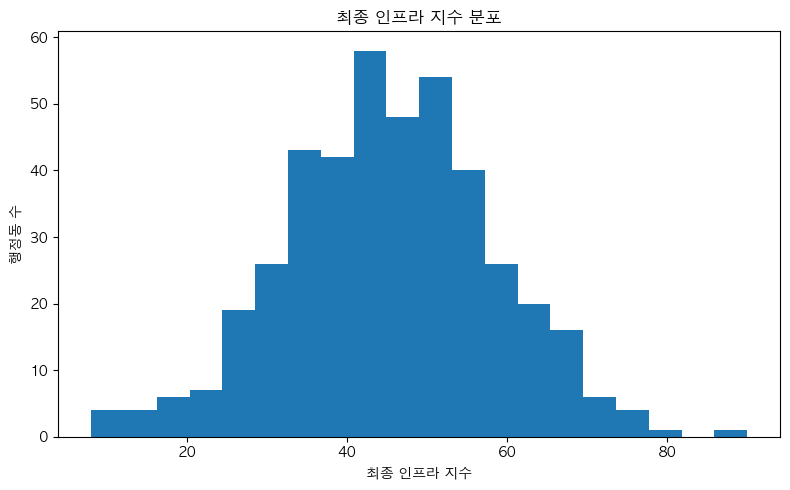

/var/folders/ts/s6560d5x4gj8rfq1g1q8q7fc0000gn/T/ipykernel_37549/3813389717.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


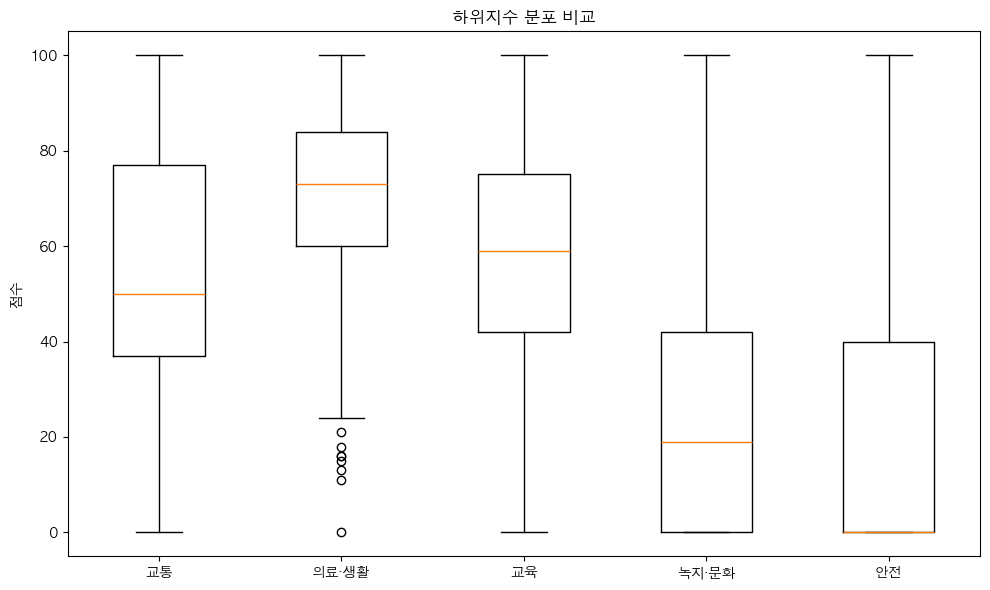

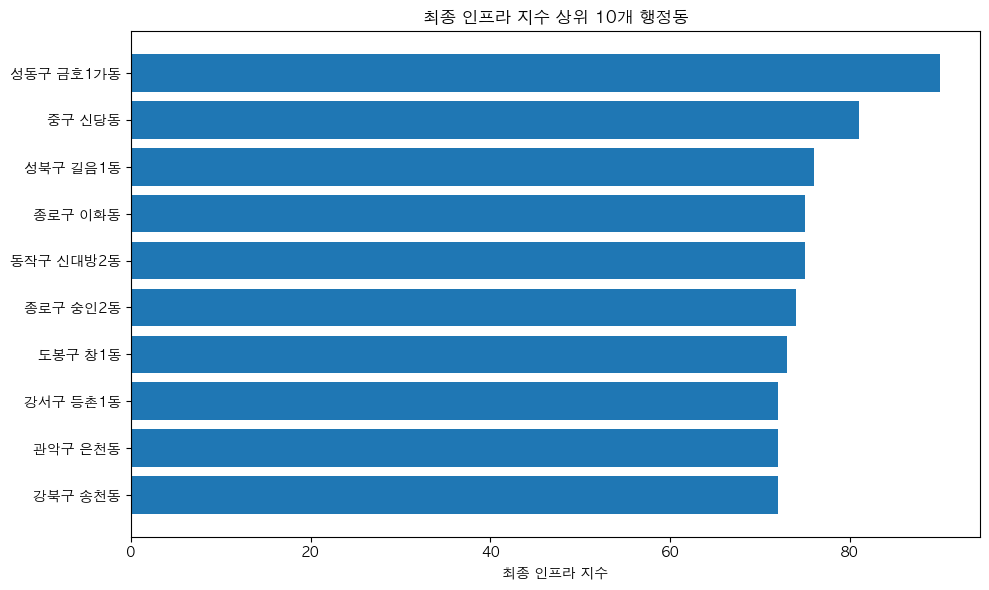

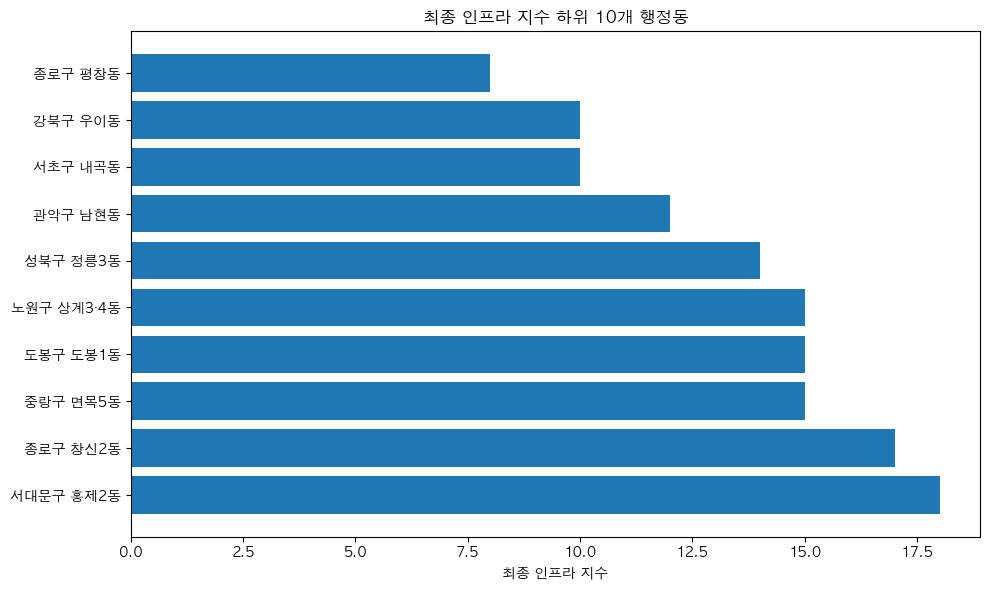

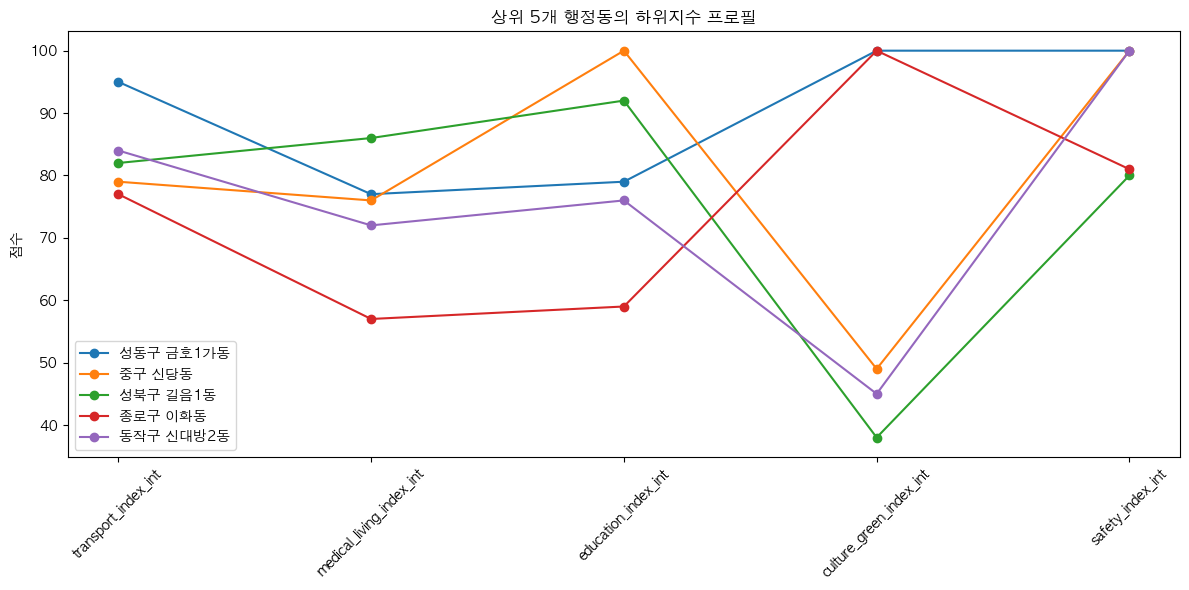

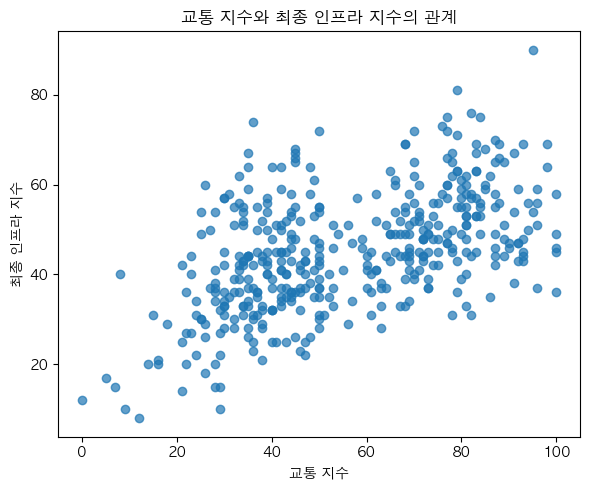

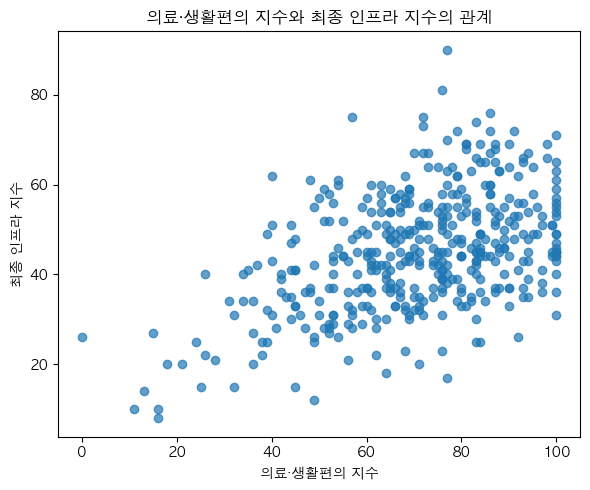

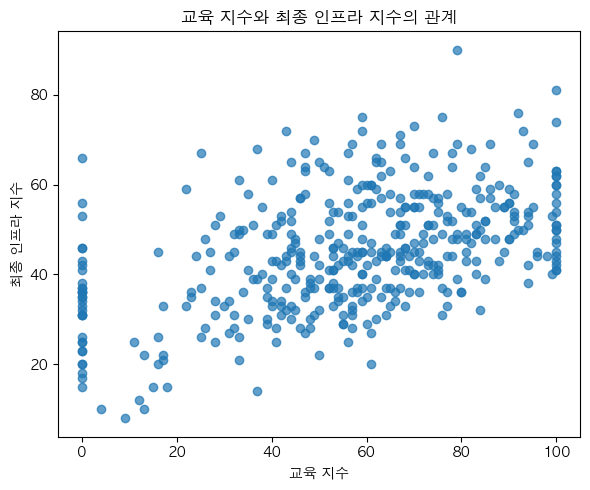

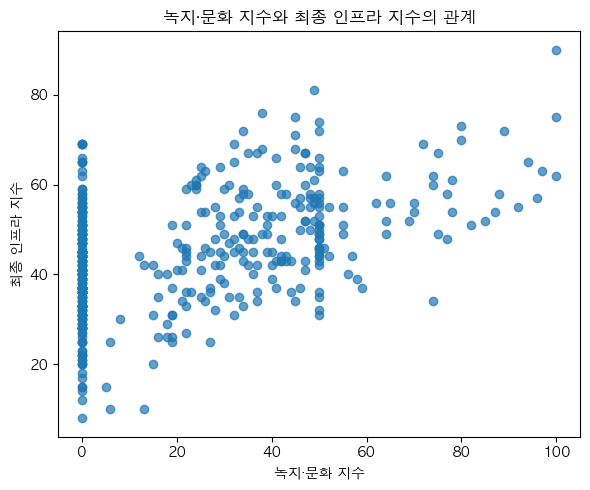

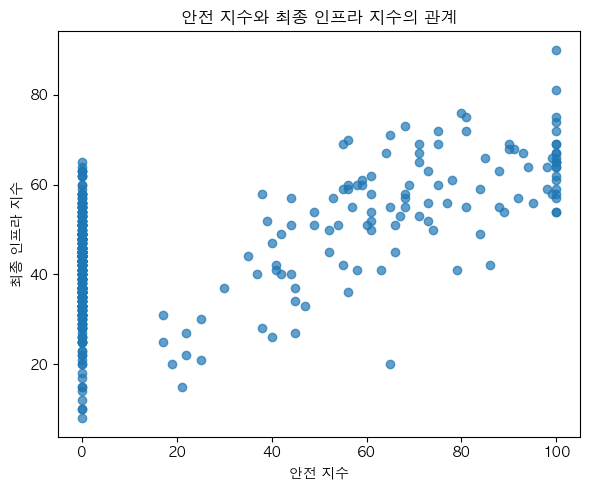

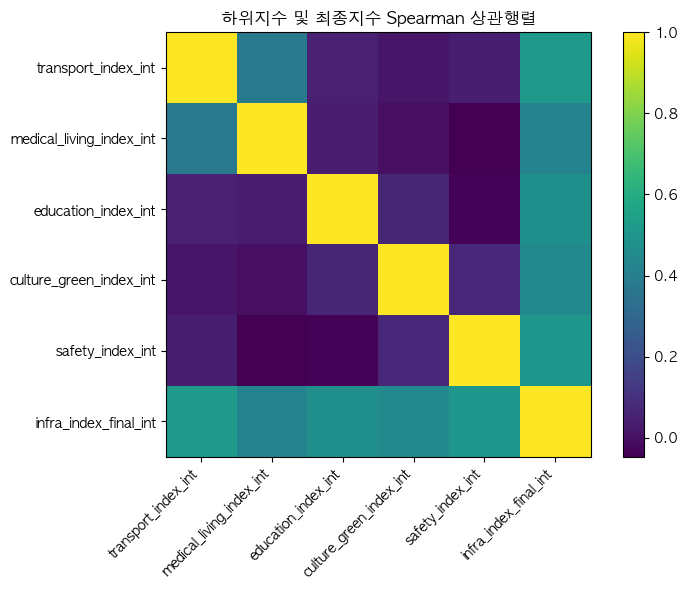


=== Spearman 상관행렬 ===
                          transport_index_int  medical_living_index_int  \
transport_index_int                  1.000000                  0.377740   
medical_living_index_int             0.377740                  1.000000   
education_index_int                  0.050050                  0.033048   
culture_green_index_int              0.015711                 -0.003256   
safety_index_int                     0.040127                 -0.047379   
infra_index_final_int                0.516429                  0.421689   

                          education_index_int  culture_green_index_int  \
transport_index_int                  0.050050                 0.015711   
medical_living_index_int             0.033048                -0.003256   
education_index_int                  1.000000                 0.067156   
culture_green_index_int              0.067156                 1.000000   
safety_index_int                    -0.039171                 0.070846   
infra_i

<Figure size 1000x1000 with 0 Axes>

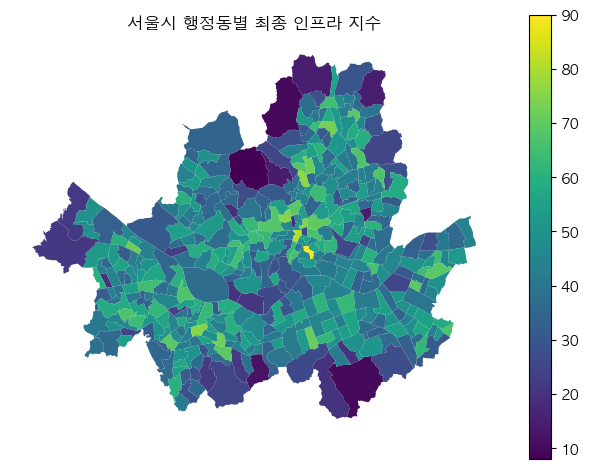


=== 저장 완료 ===
EDA 폴더: ./cleaned data/infra_final_v2_eda


In [18]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# -----------------------------
# 0. 경로 설정
# -----------------------------
detail_path = "./cleaned data/infra_final_v2/infra_index_final_detail.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"

out_dir = "./cleaned data/infra_final_v2_eda"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 한글 폰트 설정
# -----------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 2. 데이터 불러오기
# -----------------------------
df = pd.read_csv(detail_path, encoding="utf-8-sig")
df["adm_cd"] = pd.to_numeric(df["adm_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)

print("=== EDA 대상 데이터 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# -----------------------------
# 3. 기초 점검
# -----------------------------
sub_cols = [
    "transport_index_int",
    "medical_living_index_int",
    "education_index_int",
    "culture_green_index_int",
    "safety_index_int",
    "infra_index_final_int"
]

print("\n=== 하위지수 및 최종지수 기초통계 ===")
print(df[sub_cols].describe())

skew_df = pd.DataFrame({
    "variable": sub_cols,
    "skew": [df[c].skew() for c in sub_cols],
    "zero_share": [(df[c] == 0).mean() for c in sub_cols]
})
print("\n=== 왜도 및 0비율 ===")
print(skew_df)

# -----------------------------
# 4. 시각화 1: 최종 인프라 지수 분포
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["infra_index_final_int"], bins=20)
plt.xlabel("최종 인프라 지수")
plt.ylabel("행정동 수")
plt.title("최종 인프라 지수 분포")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "01_infra_index_hist.png"), dpi=200)
plt.show()

# -----------------------------
# 5. 시각화 2: 하위지수 박스플롯
# -----------------------------
plt.figure(figsize=(10, 6))
plt.boxplot(
    [df["transport_index_int"],
     df["medical_living_index_int"],
     df["education_index_int"],
     df["culture_green_index_int"],
     df["safety_index_int"]],
    labels=["교통", "의료·생활", "교육", "녹지·문화", "안전"]
)
plt.ylabel("점수")
plt.title("하위지수 분포 비교")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "02_subindex_boxplot.png"), dpi=200)
plt.show()

# -----------------------------
# 6. 시각화 3: 상위 10개 / 하위 10개
# -----------------------------
top10 = df.sort_values("infra_index_final_int", ascending=False).head(10).copy()
top10["label"] = top10["gu_nm"] + " " + top10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(top10["label"], top10["infra_index_final_int"])
plt.gca().invert_yaxis()
plt.xlabel("최종 인프라 지수")
plt.title("최종 인프라 지수 상위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "03_top10_bar.png"), dpi=200)
plt.show()

bottom10 = df.sort_values("infra_index_final_int", ascending=True).head(10).copy()
bottom10["label"] = bottom10["gu_nm"] + " " + bottom10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(bottom10["label"], bottom10["infra_index_final_int"])
plt.gca().invert_yaxis()
plt.xlabel("최종 인프라 지수")
plt.title("최종 인프라 지수 하위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "04_bottom10_bar.png"), dpi=200)
plt.show()

# -----------------------------
# 7. 시각화 4: 상위 5개 하위지수 프로필
# -----------------------------
top5 = df.sort_values("infra_index_final_int", ascending=False).head(5).copy()
top5["label"] = top5["gu_nm"] + " " + top5["adm_nm"]

profile_cols = [
    "transport_index_int",
    "medical_living_index_int",
    "education_index_int",
    "culture_green_index_int",
    "safety_index_int"
]

profile_df = top5[["label"] + profile_cols].set_index("label").T

plt.figure(figsize=(12, 6))
for col in profile_df.columns:
    plt.plot(profile_df.index, profile_df[col], marker="o", label=col)
plt.ylabel("점수")
plt.title("상위 5개 행정동의 하위지수 프로필")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "05_top5_profile.png"), dpi=200)
plt.show()

# -----------------------------
# 8. 시각화 5: 하위지수-최종지수 상관 산점도
# -----------------------------
compare_pairs = [
    ("transport_index_int", "교통"),
    ("medical_living_index_int", "의료·생활편의"),
    ("education_index_int", "교육"),
    ("culture_green_index_int", "녹지·문화"),
    ("safety_index_int", "안전")
]

for col, title in compare_pairs:
    plt.figure(figsize=(6, 5))
    plt.scatter(df[col], df["infra_index_final_int"], alpha=0.7)
    plt.xlabel(f"{title} 지수")
    plt.ylabel("최종 인프라 지수")
    plt.title(f"{title} 지수와 최종 인프라 지수의 관계")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"scatter_{col}.png"), dpi=200)
    plt.show()

# -----------------------------
# 9. 시각화 6: 하위지수 상관행렬
# -----------------------------
corr = df[profile_cols + ["infra_index_final_int"]].corr(method="spearman")

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("하위지수 및 최종지수 Spearman 상관행렬")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "06_corr_heatmap.png"), dpi=200)
plt.show()

print("\n=== Spearman 상관행렬 ===")
print(corr)

# -----------------------------
# 10. 시각화 7: 지도
# -----------------------------
base_gdf = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base")
base_gdf["adm_cd"] = pd.to_numeric(base_gdf["adm_cd"], errors="coerce").astype("Int64").astype(str).str.zfill(8)

map_df = base_gdf.merge(
    df[["adm_cd", "infra_index_final_int"]],
    on="adm_cd",
    how="left"
)

plt.figure(figsize=(10, 10))
map_df.plot(column="infra_index_final_int", legend=True)
plt.title("서울시 행정동별 최종 인프라 지수")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "07_infra_index_map.png"), dpi=200)
plt.show()

# -----------------------------
# 11. 결과 저장
# -----------------------------
skew_df.to_csv(os.path.join(out_dir, "eda_skew_zero_summary.csv"), index=False, encoding="utf-8-sig")
corr.to_csv(os.path.join(out_dir, "eda_subindex_corr.csv"), encoding="utf-8-sig")
top10.to_csv(os.path.join(out_dir, "eda_top10.csv"), index=False, encoding="utf-8-sig")
bottom10.to_csv(os.path.join(out_dir, "eda_bottom10.csv"), index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("EDA 폴더:", out_dir)

In [19]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd

# -----------------------------
# 0. 경로 설정
# -----------------------------
merged_master_path = "./cleaned data/infra_master/infra_master_by_dong_raw_merged.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"
fire_gpkg_path = "./cleaned data/infra_points/fire_station_points.gpkg"
school_points_path = "./cleaned data/infra_points/school_points.csv"

out_dir = "./cleaned data/infra_final_v3"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 공통 함수
# -----------------------------
def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA
    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

def log_cap_minmax(series, cap_q=0.99):
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)
    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    return (s_cap - min_val) / (max_val - min_val) * 100

def low_is_good_scale(series, cap_q=0.99):
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)
    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    scaled = (s_cap - min_val) / (max_val - min_val) * 100
    return 100 - scaled

def blend_count_density(count_series, density_series, cap_q=0.99, w_count=0.5, w_density=0.5):
    score_count = log_cap_minmax(count_series, cap_q=cap_q)
    score_density = log_cap_minmax(density_series, cap_q=cap_q)
    return w_count * score_count + w_density * score_density

# -----------------------------
# 2. 통합 마스터 불러오기
# -----------------------------
df = pd.read_csv(merged_master_path, encoding="utf-8-sig")

df["adm_cd"] = normalize_code(df["adm_cd"])
df["gu_cd"] = normalize_code(df["gu_cd"])
df["gu_nm"] = clean_text(df["gu_nm"])
df["adm_nm"] = clean_text(df["adm_nm"])

print("=== v2 입력 데이터 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# -----------------------------
# 3. density 재계산
# -----------------------------
count_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    df[density_col] = np.where(
        df["area_km2"] > 0,
        df[col] / df["area_km2"],
        0
    )

# 승하차량은 보조 변수로만 유지
df["subway_total_ridership_density"] = np.where(
    df["area_km2"] > 0,
    df["subway_total_ridership_sum"] / df["area_km2"],
    0
)

# -----------------------------
# 4. 학교급 가중치 반영
#    school_points.csv를 사용해 weighted school count 재생성
# -----------------------------
school = pd.read_csv(school_points_path, encoding="utf-8-sig")
school.columns = [str(c).strip() for c in school.columns]

school["gu_nm"] = clean_text(school["gu_nm"])
school["adm_nm"] = clean_text(school["adm_nm"]).apply(standardize_dong_name)
school["merge_key"] = school["gu_nm"] + "_" + school["adm_nm"]

# school_type 컬럼 탐색
school_type_col = None
for c in ["school_type", "학교종류명"]:
    if c in school.columns:
        school_type_col = c
        break

if school_type_col is None:
    raise ValueError("school_points.csv에서 학교 유형 컬럼을 찾지 못했습니다.")

school[school_type_col] = clean_text(school[school_type_col]).fillna("기타")

def school_weight(x):
    s = str(x).strip()

    weight_map = {
        "초등학교": 1.0,
        "각종학교(초)": 1.0,
        "평생학교(초)-3년6학기": 0.6,

        "중학교": 0.9,
        "각종학교(중)": 0.9,
        "방송통신중학교": 0.5,
        "평생학교(중)-2년6학기": 0.5,

        "고등학교": 0.8,
        "각종학교(고)": 0.7,
        "방송통신고등학교": 0.5,
        "평생학교(고)-3년6학기": 0.4,
        "평생학교(고)-2년6학기": 0.4,
        "고등기술학교": 0.4,

        "특수학교": 0.8,
        "외국인학교": 0.4,
        "공동실습소": 0.2,
    }

    return weight_map.get(s, 0.5)

school["school_weight"] = school[school_type_col].apply(school_weight)

school_weighted = (
    school.groupby("merge_key", as_index=False)
    .agg(weighted_school_count=("school_weight", "sum"))
)

df["merge_key"] = df["gu_nm"] + "_" + df["adm_nm"]
df = df.merge(school_weighted, how="left", on="merge_key")
df["weighted_school_count"] = df["weighted_school_count"].fillna(0)

df["weighted_school_density"] = np.where(
    df["area_km2"] > 0,
    df["weighted_school_count"] / df["area_km2"],
    0
)

# -----------------------------
# 5. 소방 접근성(최근접 거리) 생성
#    count 대신 최근접 소방시설 거리 사용
# -----------------------------
base_gdf = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base").to_crs(epsg=5179)
base_gdf["adm_cd"] = normalize_code(base_gdf["adm_cd"])
base_gdf["gu_nm"] = clean_text(base_gdf["gu_nm"])
base_gdf["adm_nm"] = clean_text(base_gdf["adm_nm"]).apply(standardize_dong_name)
base_gdf["merge_key"] = base_gdf["gu_nm"] + "_" + base_gdf["adm_nm"]

# merge_key 기준 dissolve -> 425개 geometry
base_diss = base_gdf.dissolve(by="merge_key", aggfunc="first").reset_index()

# 대표점 생성
rep = base_diss.copy()
rep["geometry"] = rep.representative_point()

# 소방 포인트
fire = gpd.read_file(fire_gpkg_path).to_crs(epsg=5179)

# 최근접 거리 계산
rep_nearest = gpd.sjoin_nearest(
    rep[["merge_key", "geometry"]],
    fire[["geometry"]],
    how="left",
    distance_col="nearest_fire_dist_m"
).drop(columns=["index_right"], errors="ignore")

# merge_key별 최솟값만 남겨서 1행화
fire_access = (
    rep_nearest[["merge_key", "nearest_fire_dist_m"]]
    .groupby("merge_key", as_index=False)
    .agg(nearest_fire_dist_m=("nearest_fire_dist_m", "min"))
)

fire_access["nearest_fire_dist_km"] = fire_access["nearest_fire_dist_m"] / 1000

df = df.merge(
    fire_access[["merge_key", "nearest_fire_dist_km"]],
    how="left",
    on="merge_key"
)
# -----------------------------
# 6. v2 스코어 생성
#    count + density 혼합
# -----------------------------
df["score_bus_v2"] = blend_count_density(df["bus_stop_count"], df["bus_stop_density"], cap_q=0.99)
df["score_hospital_v2"] = blend_count_density(df["hospital_count"], df["hospital_density"], cap_q=0.99)
df["score_library_v2"] = blend_count_density(df["library_count"], df["library_density"], cap_q=0.99)
df["score_park_v2"] = blend_count_density(df["park_count"], df["park_density"], cap_q=0.99)
df["score_subway_station_v2"] = blend_count_density(df["subway_station_count"], df["subway_station_density"], cap_q=0.99)

# 학교는 가중 학교 수 사용
df["score_school_v2"] = blend_count_density(df["weighted_school_count"], df["weighted_school_density"], cap_q=0.99)

# 안전은 최근접 거리(낮을수록 좋음)
df["score_fire_access_v2"] = low_is_good_scale(df["nearest_fire_dist_km"], cap_q=0.99)

# -----------------------------
# 7. 하위지수 계산
#    지하철 승하차는 최종 지수에서 제외
# -----------------------------
df["transport_index_v2"] = (
    0.70 * df["score_bus_v2"] +
    0.30 * df["score_subway_station_v2"]
)

df["medical_living_index_v2"] = df["score_hospital_v2"]
df["education_index_v2"] = df["score_school_v2"]

df["culture_green_index_v2"] = (
    0.50 * df["score_library_v2"] +
    0.50 * df["score_park_v2"]
)

df["safety_index_v2"] = df["score_fire_access_v2"]

# -----------------------------
# 8. 최종지수 계산
#    탐색적 가중치
# -----------------------------
df["infra_index_v2"] = (
    0.30 * df["transport_index_v2"] +
    0.25 * df["medical_living_index_v2"] +
    0.20 * df["education_index_v2"] +
    0.15 * df["culture_green_index_v2"] +
    0.10 * df["safety_index_v2"]
).clip(0, 100)

# 정수화
score_cols = [
    "score_bus_v2", "score_hospital_v2", "score_library_v2", "score_park_v2",
    "score_subway_station_v2", "score_school_v2", "score_fire_access_v2",
    "transport_index_v2", "medical_living_index_v2", "education_index_v2",
    "culture_green_index_v2", "safety_index_v2", "infra_index_v2"
]

for col in score_cols:
    df[f"{col}_int"] = df[col].round().astype(int)

df["infra_rank_v2"] = df["infra_index_v2"].rank(method="min", ascending=False).astype(int)

# -----------------------------
# 9. 기본 점검
# -----------------------------
print("\n=== v2 최종지수 기본 점검 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())
print("지수 최소/최대:", df["infra_index_v2_int"].min(), df["infra_index_v2_int"].max())

print("\n=== 상위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v2_int", "infra_rank_v2"]]
    .sort_values("infra_index_v2_int", ascending=False)
    .head(10)
)

print("\n=== 하위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v2_int", "infra_rank_v2"]]
    .sort_values("infra_index_v2_int", ascending=True)
    .head(10)
)

# -----------------------------
# 10. 저장
# -----------------------------
detail_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "merge_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "weighted_school_count", "subway_station_count",
    "subway_total_ridership_sum",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "fire_station_density", "school_density", "weighted_school_density",
    "subway_station_density", "subway_total_ridership_density",
    "nearest_fire_dist_km",
    "score_bus_v2_int", "score_hospital_v2_int", "score_library_v2_int", "score_park_v2_int",
    "score_subway_station_v2_int", "score_school_v2_int", "score_fire_access_v2_int",
    "transport_index_v2_int", "medical_living_index_v2_int", "education_index_v2_int",
    "culture_green_index_v2_int", "safety_index_v2_int",
    "infra_index_v2_int", "infra_rank_v2"
]

detail_path = os.path.join(out_dir, "infra_index_v2_detail.csv")
df[detail_cols].to_csv(detail_path, index=False, encoding="utf-8-sig")

submit = df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v2_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_v2_int": "지수"
})
submit_path = os.path.join(out_dir, "infra_index_v2_submit.csv")
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")
print("fire_access 행 수:", len(fire_access))
print("fire_access 고유 merge_key 수:", fire_access["merge_key"].nunique())
print("df 행 수(merge 전):", len(df))
print("\n=== 저장 완료 ===")
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)

=== v2 입력 데이터 ===
행 수: 425
행정동코드 고유값 수: 425

=== v2 최종지수 기본 점검 ===
행 수: 425
행정동코드 고유값 수: 425
지수 최소/최대: 16 72

=== 상위 10개 ===
    gu_nm       adm_nm    adm_cd  infra_index_v2_int  infra_rank_v2
184   동작구          대방동  11200680                  72              1
239   서초구         서초2동  11220520                  71              2
170  동대문구          용신동  11060810                  69              3
25    강동구           길동  11250740                  69              5
245   성동구        금호1가동  11040590                  69              4
59    강서구         등촌3동  11160540                  68              6
398    중구          소공동  11020520                  67             10
260   성동구         행당1동  11040560                  67              9
410   중랑구         망우본동  11070730                  67              8
386   종로구  종로1·2·3·4가동  11010610                  67              7

=== 하위 10개 ===
    gu_nm  adm_nm    adm_cd  infra_index_v2_int  infra_rank_v2
353   용산구    이촌2동  11030640                  16 

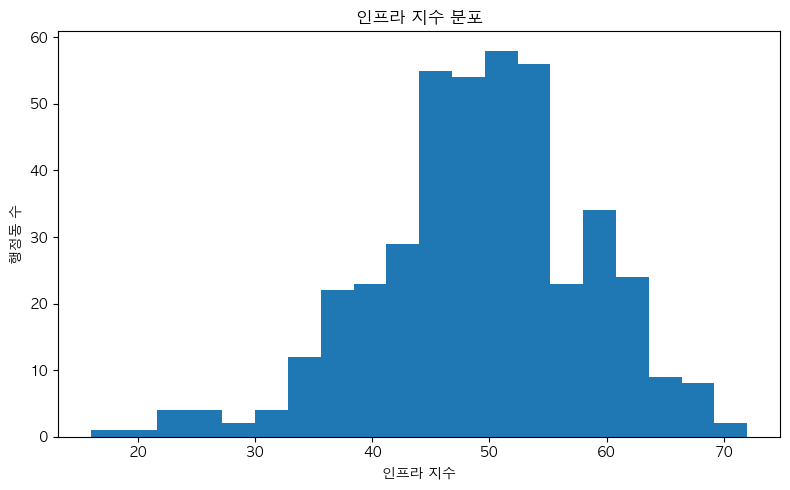

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

detail_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
out_dir = "./cleaned data/infra_final_v3_fig"
os.makedirs(out_dir, exist_ok=True)

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(detail_path, encoding="utf-8-sig")

plt.figure(figsize=(8, 5))
plt.hist(df["infra_index_v2_int"], bins=20)
plt.xlabel("인프라 지수")
plt.ylabel("행정동 수")
plt.title("인프라 지수 분포")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "01_infra_index_v2_hist.png"), dpi=200)
plt.show()

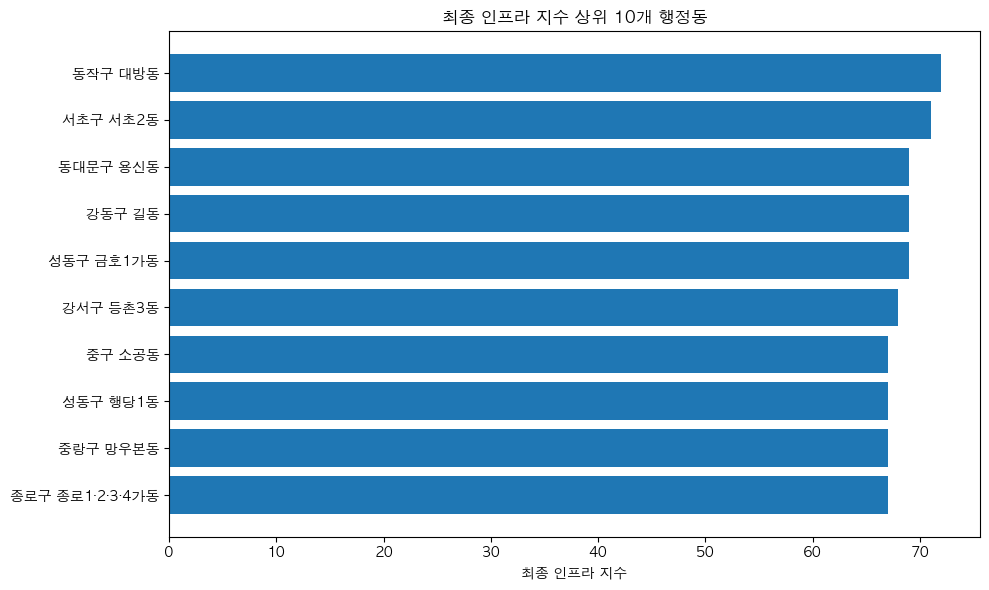

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

detail_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
out_dir = "./cleaned data/infra_final_v3_fig"
os.makedirs(out_dir, exist_ok=True)

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(detail_path, encoding="utf-8-sig")
top10 = df.sort_values("infra_index_v2_int", ascending=False).head(10).copy()
top10["label"] = top10["gu_nm"] + " " + top10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(top10["label"], top10["infra_index_v2_int"])
plt.gca().invert_yaxis()
plt.xlabel("최종 인프라 지수")
plt.title("최종 인프라 지수 상위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "02_top10_v2.png"), dpi=200)
plt.show()

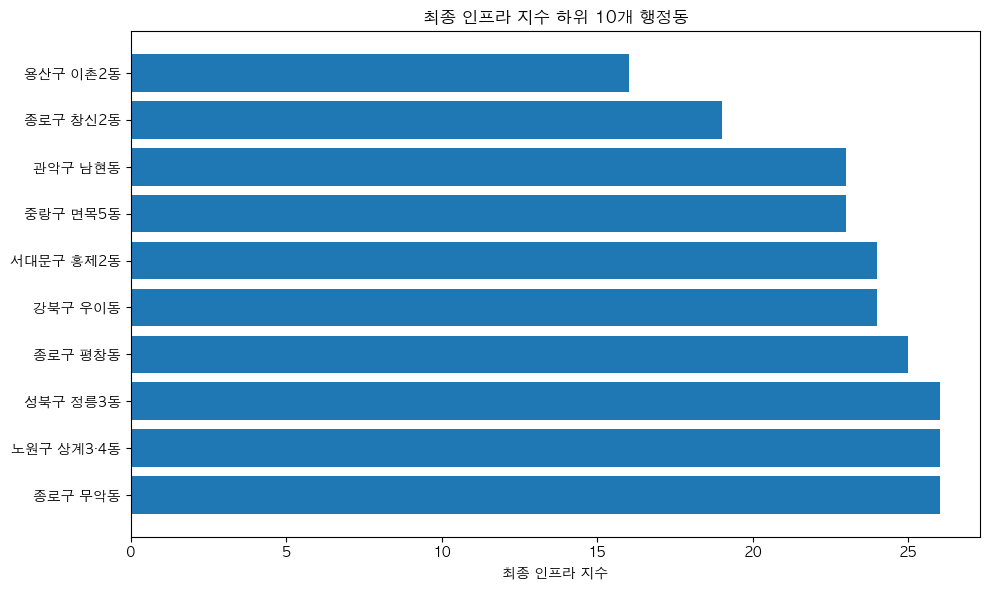

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

detail_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
out_dir = "./cleaned data/infra_final_v3_fig"
os.makedirs(out_dir, exist_ok=True)

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(detail_path, encoding="utf-8-sig")
bottom10 = df.sort_values("infra_index_v2_int", ascending=True).head(10).copy()
bottom10["label"] = bottom10["gu_nm"] + " " + bottom10["adm_nm"]

plt.figure(figsize=(10, 6))
plt.barh(bottom10["label"], bottom10["infra_index_v2_int"])
plt.gca().invert_yaxis()
plt.xlabel("최종 인프라 지수")
plt.title("최종 인프라 지수 하위 10개 행정동")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "03_bottom10_v2.png"), dpi=200)
plt.show()

<Figure size 1000x1000 with 0 Axes>

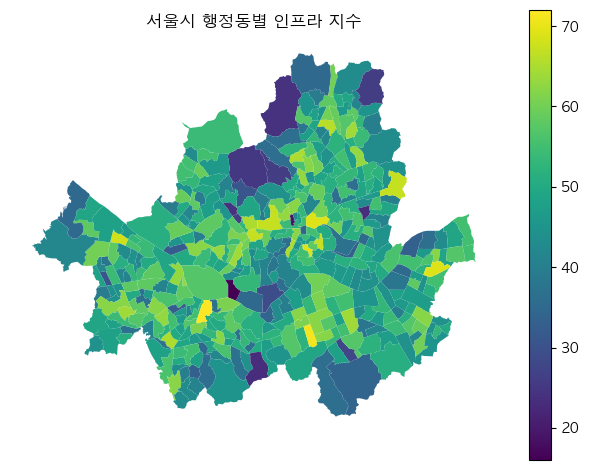

In [23]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

detail_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"
out_dir = "./cleaned data/infra_final_v3_fig"
os.makedirs(out_dir, exist_ok=True)

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

df = pd.read_csv(detail_path, encoding="utf-8-sig")
df["adm_cd"] = normalize_code(df["adm_cd"])

gdf = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base")
gdf["adm_cd"] = normalize_code(gdf["adm_cd"])

# 동일 명칭 통합 반영 위해 merge_key 맞추기
gdf["gu_nm"] = gdf["gu_nm"].astype(str).str.strip()
gdf["adm_nm"] = gdf["adm_nm"].astype(str).str.strip()

def std_name(x):
    x = str(x).strip().replace(" ", "")
    mapping = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉"
    }
    if x in mapping:
        return mapping[x]
    if x in ["상계3,4동", "상계3_4동", "상계3·4동"]:
        return "상계3·4동"
    return x

gdf["adm_nm"] = gdf["adm_nm"].apply(std_name)
gdf["merge_key"] = gdf["gu_nm"] + "_" + gdf["adm_nm"]

map_df = gdf.merge(df[["merge_key", "infra_index_v2_int"]], on="merge_key", how="left")

plt.figure(figsize=(10, 10))
map_df.plot(column="infra_index_v2_int", legend=True)
plt.title("서울시 행정동별 인프라 지수")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "04_map_v2.png"), dpi=200)
plt.show()

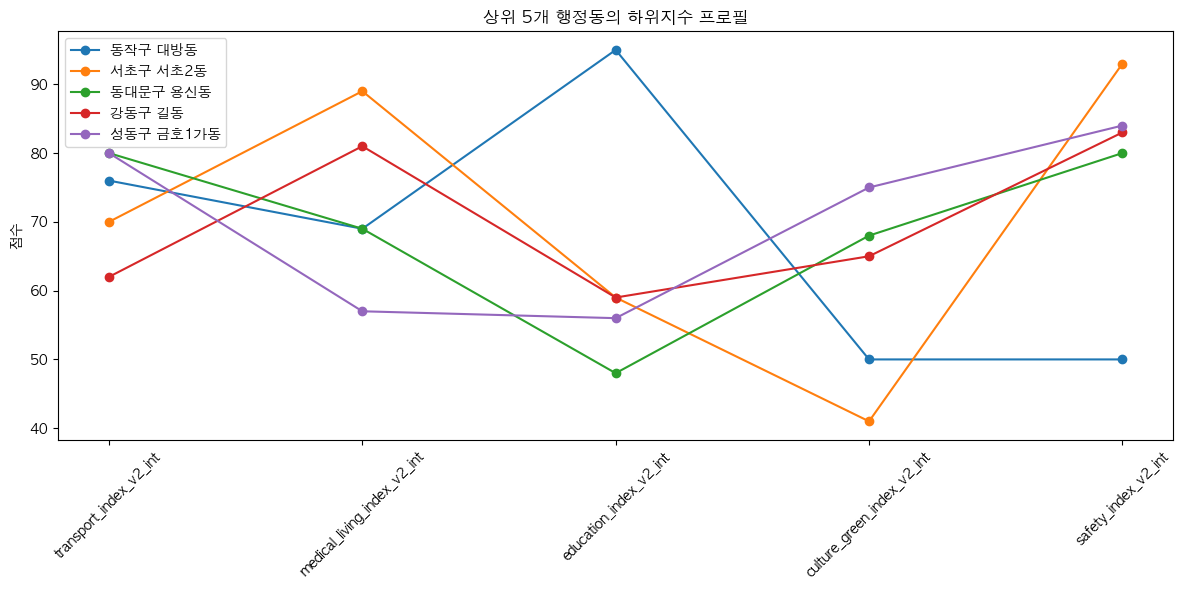

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

detail_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
out_dir = "./cleaned data/infra_final_v3_fig"
os.makedirs(out_dir, exist_ok=True)

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(detail_path, encoding="utf-8-sig")

top5 = df.sort_values("infra_index_v2_int", ascending=False).head(5).copy()
top5["label"] = top5["gu_nm"] + " " + top5["adm_nm"]

cols = [
    "transport_index_v2_int",
    "medical_living_index_v2_int",
    "education_index_v2_int",
    "culture_green_index_v2_int",
    "safety_index_v2_int"
]

plot_df = top5[["label"] + cols].set_index("label").T

plt.figure(figsize=(12, 6))
for col in plot_df.columns:
    plt.plot(plot_df.index, plot_df[col], marker="o", label=col)
plt.ylabel("점수")
plt.title("상위 5개 행정동의 하위지수 프로필")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "05_top5_profile_v2.png"), dpi=200)
plt.show()

=== 비교 가능 행정동 수(결측 제거 후) ===
408

=== 유사도 표 ===
                               지표           값
0                     비교 가능 행정동 수  408.000000
1                     Spearman 상관    0.356417
2             Pearson 상관(z-score)    0.348974
3              KS 통계량(percentile)    0.029412
4      Wasserstein 거리(percentile)    0.853037
5                      상위 20% 일치율    0.378049
6                      하위 20% 일치율    0.390244
7  자치구 평균 패턴 Spearman(percentile)    0.168462
8  자치구 편차 패턴 Spearman(percentile)    0.160769
9              종합 유사도 점수(100점 만점)   34.406702


<Figure size 1000x1000 with 0 Axes>

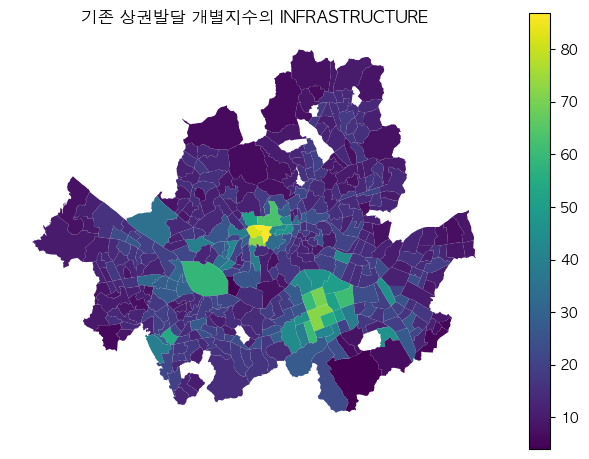

<Figure size 1000x1000 with 0 Axes>

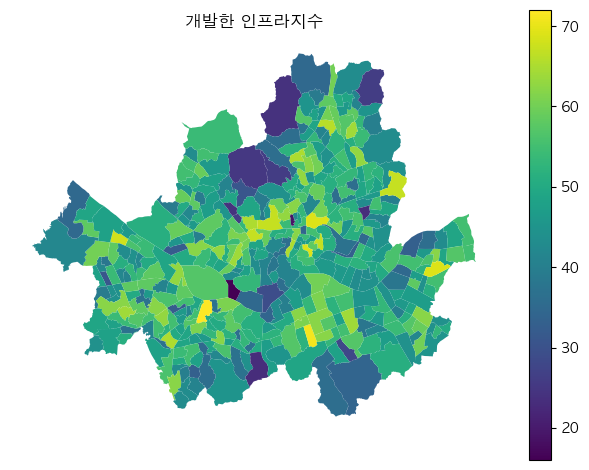

<Figure size 1000x1000 with 0 Axes>

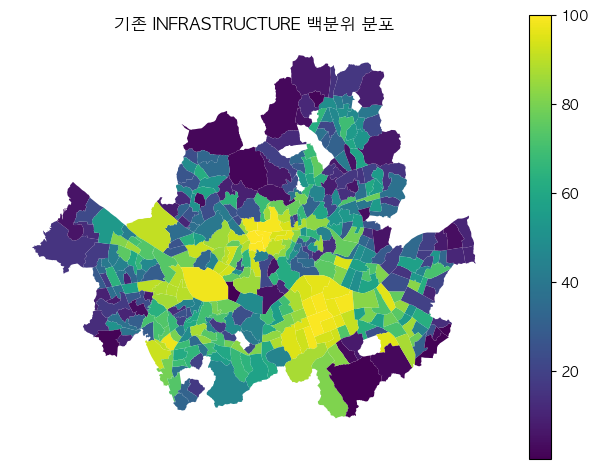

<Figure size 1000x1000 with 0 Axes>

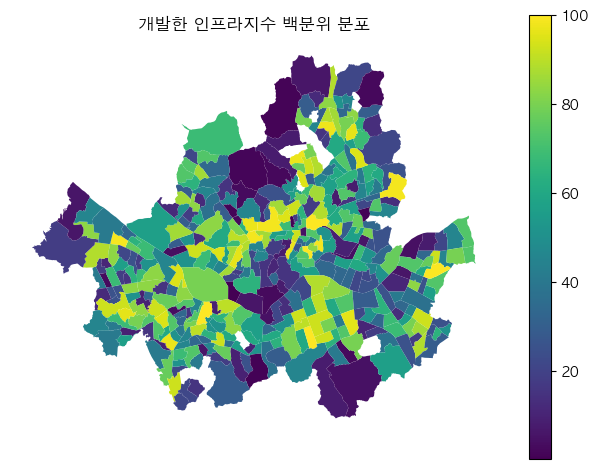

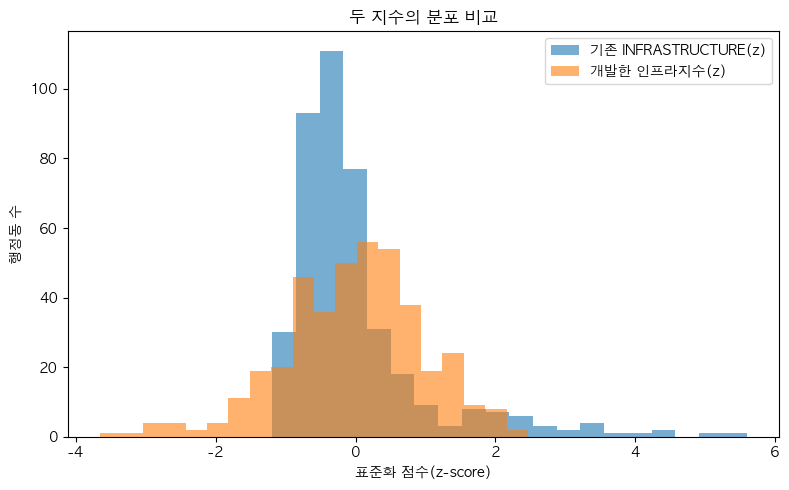

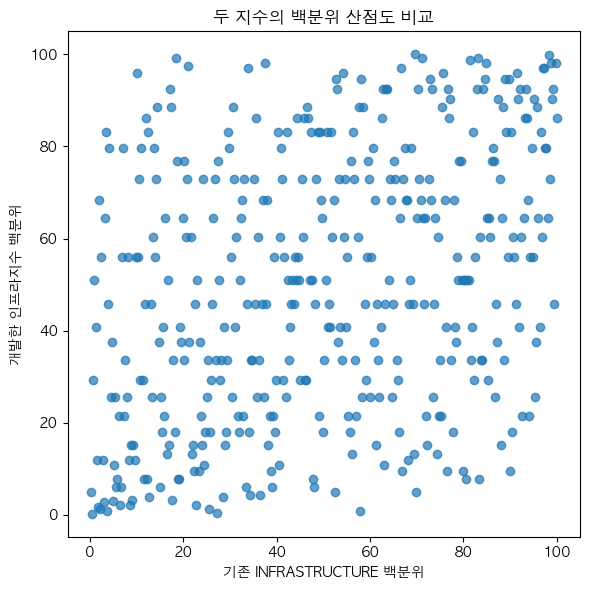


=== 저장 완료 ===
비교 상세: ./cleaned data/infra_compare_v2/compare_detail.csv
유사도 표: ./cleaned data/infra_compare_v2/similarity_table.csv
자치구 비교표: ./cleaned data/infra_compare_v2/district_pattern_compare.csv


In [25]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import spearmanr, pearsonr, wasserstein_distance, ks_2samp

# -----------------------------
# 0. 경로 설정
# -----------------------------
my_index_path = "./cleaned data/infra_final_v3/infra_index_v2_detail.csv"
ref_path = "./data/raw data/서울시 행정동별 상권발달 개별지수.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"

out_dir = "./cleaned data/infra_compare_v2"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 한글 폰트 설정
# -----------------------------
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break
plt.rcParams["axes.unicode_minus"] = False

# -----------------------------
# 2. 공통 함수
# -----------------------------
def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA
    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

def zscore(s):
    s = pd.to_numeric(s, errors="coerce")
    return (s - s.mean()) / s.std(ddof=0)

def percentile_100(s):
    s = pd.to_numeric(s, errors="coerce")
    return s.rank(method="average", pct=True) * 100

# -----------------------------
# 3. 현재 인프라지수 로드
# -----------------------------
my = pd.read_csv(my_index_path, encoding="utf-8-sig")
my["adm_cd"] = normalize_code(my["adm_cd"])
my["gu_nm"] = clean_text(my["gu_nm"])
my["adm_nm"] = clean_text(my["adm_nm"]).apply(standardize_dong_name)
my["merge_key"] = my["gu_nm"] + "_" + my["adm_nm"]

my_use = my[["gu_nm", "adm_nm", "adm_cd", "merge_key", "infra_index_v2_int"]].copy()
my_use = my_use.rename(columns={"infra_index_v2_int": "my_index"})

# -----------------------------
# 4. 기존 INFRASTRUCTURE 로드
#    2018~2019 평균 사용
# -----------------------------
ref = pd.read_csv(ref_path, encoding="utf-8-sig")
ref["행정구명"] = clean_text(ref["행정구명"])
ref["행정동명"] = clean_text(ref["행정동명"]).apply(standardize_dong_name)
ref["merge_key"] = ref["행정구명"] + "_" + ref["행정동명"]

ref_agg = (
    ref[ref["연도"].isin([2018, 2019])]
    .groupby(["행정구명", "행정동명", "merge_key"], as_index=False)
    .agg(
        ref_infra=("INFRASTRUCTURE", "mean"),
        ref_n=("INFRASTRUCTURE", "size")
    )
    .rename(columns={"행정구명": "gu_nm", "행정동명": "adm_nm"})
)

# -----------------------------
# 5. 비교 데이터 생성 + 결측 제거
# -----------------------------
cmp = my_use.merge(
    ref_agg[["merge_key", "ref_infra", "ref_n"]],
    how="inner",
    on="merge_key"
)

cmp["my_index"] = pd.to_numeric(cmp["my_index"], errors="coerce")
cmp["ref_infra"] = pd.to_numeric(cmp["ref_infra"], errors="coerce")

# 핵심: 비교 통계 전에 결측 제거
cmp = cmp.dropna(subset=["my_index", "ref_infra"]).copy()

print("=== 비교 가능 행정동 수(결측 제거 후) ===")
print(len(cmp))

# 표준화 / 백분위
cmp["my_index_z"] = zscore(cmp["my_index"])
cmp["ref_infra_z"] = zscore(cmp["ref_infra"])

cmp["my_pct"] = percentile_100(cmp["my_index"])
cmp["ref_pct"] = percentile_100(cmp["ref_infra"])

# -----------------------------
# 6. 유사도 지표 계산
# -----------------------------
spearman_val = spearmanr(cmp["my_index"], cmp["ref_infra"]).statistic
pearson_z = pearsonr(cmp["my_index_z"], cmp["ref_infra_z"])[0]

# 분포 유사도는 z-score 또는 percentile 기준으로 계산
ks_stat = ks_2samp(cmp["my_pct"], cmp["ref_pct"]).statistic
wasser = wasserstein_distance(cmp["my_pct"], cmp["ref_pct"])

# 상위/하위 20% 일치율
n = len(cmp)
k = max(1, int(np.ceil(n * 0.2)))

top_my = set(cmp.sort_values("my_index", ascending=False).head(k)["merge_key"])
top_ref = set(cmp.sort_values("ref_infra", ascending=False).head(k)["merge_key"])

bottom_my = set(cmp.sort_values("my_index", ascending=True).head(k)["merge_key"])
bottom_ref = set(cmp.sort_values("ref_infra", ascending=True).head(k)["merge_key"])

top_overlap = len(top_my & top_ref) / k
bottom_overlap = len(bottom_my & bottom_ref) / k

# 자치구 패턴 비교는 raw가 아니라 percentile 평균/표준편차 기준으로
gu_cmp = (
    cmp.groupby("gu_nm", as_index=False)
    .agg(
        my_mean_pct=("my_pct", "mean"),
        my_std_pct=("my_pct", "std"),
        ref_mean_pct=("ref_pct", "mean"),
        ref_std_pct=("ref_pct", "std")
    )
)

gu_mean_spearman = spearmanr(gu_cmp["my_mean_pct"], gu_cmp["ref_mean_pct"]).statistic
gu_std_spearman = spearmanr(gu_cmp["my_std_pct"], gu_cmp["ref_std_pct"]).statistic

# 종합 유사도 점수(100점 만점)
# scale 차이를 덜 타도록 rank/pct 중심 가중
similarity_score = (
    40 * max(spearman_val, 0) +
    20 * max(pearson_z, 0) +
    15 * top_overlap +
    15 * bottom_overlap +
    5 * max(gu_mean_spearman, 0) +
    5 * max(gu_std_spearman, 0)
)

similarity_table = pd.DataFrame({
    "지표": [
        "비교 가능 행정동 수",
        "Spearman 상관",
        "Pearson 상관(z-score)",
        "KS 통계량(percentile)",
        "Wasserstein 거리(percentile)",
        "상위 20% 일치율",
        "하위 20% 일치율",
        "자치구 평균 패턴 Spearman(percentile)",
        "자치구 편차 패턴 Spearman(percentile)",
        "종합 유사도 점수(100점 만점)"
    ],
    "값": [
        len(cmp),
        spearman_val,
        pearson_z,
        ks_stat,
        wasser,
        top_overlap,
        bottom_overlap,
        gu_mean_spearman,
        gu_std_spearman,
        similarity_score
    ]
})

print("\n=== 유사도 표 ===")
print(similarity_table)

# -----------------------------
# 7. 지도 시각화용 데이터
# -----------------------------
base = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base")
base["adm_cd"] = normalize_code(base["adm_cd"])
base["gu_nm"] = clean_text(base["gu_nm"])
base["adm_nm"] = clean_text(base["adm_nm"]).apply(standardize_dong_name)
base["merge_key"] = base["gu_nm"] + "_" + base["adm_nm"]

# 원점수 지도
map_my = base.merge(
    my_use[["merge_key", "my_index"]],
    how="left",
    on="merge_key"
)

map_ref = base.merge(
    ref_agg[["merge_key", "ref_infra"]],
    how="left",
    on="merge_key"
)

# percentile 지도: 패턴 비교용
map_cmp = base.merge(
    cmp[["merge_key", "my_pct", "ref_pct"]],
    how="left",
    on="merge_key"
)

# -----------------------------
# 8. 지도 저장
# -----------------------------
plt.figure(figsize=(10, 10))
map_ref.plot(column="ref_infra", legend=True)
plt.title("기존 상권발달 개별지수의 INFRASTRUCTURE")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "01_ref_raw_map.png"), dpi=220)
plt.show()

plt.figure(figsize=(10, 10))
map_my.plot(column="my_index", legend=True)
plt.title("개발한 인프라지수")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "02_my_raw_map.png"), dpi=220)
plt.show()

# 비교용 percentile 지도
plt.figure(figsize=(10, 10))
map_cmp.plot(column="ref_pct", legend=True)
plt.title("기존 INFRASTRUCTURE 백분위 분포")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "03_ref_percentile_map.png"), dpi=220)
plt.show()

plt.figure(figsize=(10, 10))
map_cmp.plot(column="my_pct", legend=True)
plt.title("개발한 인프라지수 백분위 분포")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "04_my_percentile_map.png"), dpi=220)
plt.show()

# -----------------------------
# 9. 분포 비교
# -----------------------------
plt.figure(figsize=(8, 5))
plt.hist(cmp["ref_infra_z"], bins=20, alpha=0.6, label="기존 INFRASTRUCTURE(z)")
plt.hist(cmp["my_index_z"], bins=20, alpha=0.6, label="개발한 인프라지수(z)")
plt.xlabel("표준화 점수(z-score)")
plt.ylabel("행정동 수")
plt.title("두 지수의 분포 비교")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "05_distribution_compare.png"), dpi=220)
plt.show()

# -----------------------------
# 10. 산점도
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(cmp["ref_pct"], cmp["my_pct"], alpha=0.7)
plt.xlabel("기존 INFRASTRUCTURE 백분위")
plt.ylabel("개발한 인프라지수 백분위")
plt.title("두 지수의 백분위 산점도 비교")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "06_scatter_compare_pct.png"), dpi=220)
plt.show()

# -----------------------------
# 11. 저장
# -----------------------------
cmp.to_csv(os.path.join(out_dir, "compare_detail.csv"), index=False, encoding="utf-8-sig")
similarity_table.to_csv(os.path.join(out_dir, "similarity_table.csv"), index=False, encoding="utf-8-sig")
gu_cmp.to_csv(os.path.join(out_dir, "district_pattern_compare.csv"), index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("비교 상세:", os.path.join(out_dir, "compare_detail.csv"))
print("유사도 표:", os.path.join(out_dir, "similarity_table.csv"))
print("자치구 비교표:", os.path.join(out_dir, "district_pattern_compare.csv"))

In [26]:
import os
import time
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# -----------------------------
# 0. 경로 및 API 키 설정
# -----------------------------
KAKAO_REST_API_KEY = 'b37dd99d0b1517e4c7783e9900430237'

police_csv_path = "./경찰청_전국 경찰서 명칭 및 주소_20230627.csv"
out_dir = "./cleaned data/police"
os.makedirs(out_dir, exist_ok=True)

geocoded_csv_path = os.path.join(out_dir, "police_station_geocoded.csv")
geocoded_gpkg_path = os.path.join(out_dir, "police_station_points.gpkg")

# -----------------------------
# 1. CSV 불러오기
# -----------------------------
def read_korean_csv(path):
    for enc in ["cp949", "euc-kr", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise ValueError(f"CSV를 읽을 수 없습니다: {path}")

police = read_korean_csv(police_csv_path)
police.columns = [str(c).strip() for c in police.columns]

print("원본 컬럼:", police.columns.tolist())
print("원본 행 수:", len(police))

# -----------------------------
# 2. 서울 경찰서만 필터링
# -----------------------------
# 컬럼명 후보 처리
col_agency = None
col_location = None
col_name = None
col_addr = None

for c in police.columns:
    if "시도경찰청" in c:
        col_agency = c
    elif c == "위치":
        col_location = c
    elif "명칭" in c or "경찰서명" in c:
        col_name = c
    elif "주소" in c:
        col_addr = c

if col_name is None or col_addr is None:
    raise ValueError("경찰서명칭/경찰서주소 컬럼을 찾지 못했습니다.")

if col_agency is not None:
    police_seoul = police[police[col_agency].astype(str).str.contains("서울", na=False)].copy()
elif col_location is not None:
    police_seoul = police[police[col_location].astype(str).str.contains("서울", na=False)].copy()
else:
    police_seoul = police[police[col_addr].astype(str).str.contains("서울|중구|종로구|용산구|성동구|광진구|동대문구|중랑구|성북구|강북구|도봉구|노원구|은평구|서대문구|마포구|양천구|강서구|구로구|금천구|영등포구|동작구|관악구|서초구|강남구|송파구|강동구", na=False)].copy()

police_seoul = police_seoul[[col_name, col_addr]].copy()
police_seoul.columns = ["police_name", "police_addr"]

# 주소 앞에 서울특별시가 없으면 붙이기
police_seoul["search_addr"] = police_seoul["police_addr"].astype(str).str.strip()
police_seoul["search_addr"] = police_seoul["search_addr"].apply(
    lambda x: x if x.startswith("서울") else f"서울특별시 {x}"
)

police_seoul = police_seoul.drop_duplicates(subset=["police_name", "search_addr"]).reset_index(drop=True)

print("서울 경찰서 행 수:", len(police_seoul))
print(police_seoul.head())

# -----------------------------
# 3. 카카오 주소 검색 함수
# -----------------------------
headers = {
    "Authorization": f"KakaoAK {KAKAO_REST_API_KEY}"
}

def geocode_kakao_address(addr):
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    params = {"query": addr}
    r = requests.get(url, headers=headers, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()

    if data.get("documents"):
        doc = data["documents"][0]
        return {
            "lon": float(doc["x"]),
            "lat": float(doc["y"]),
            "match_type": "address"
        }
    return None

def geocode_kakao_keyword(keyword):
    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    params = {"query": keyword}
    r = requests.get(url, headers=headers, params=params, timeout=20)
    r.raise_for_status()
    data = r.json()

    if data.get("documents"):
        doc = data["documents"][0]
        return {
            "lon": float(doc["x"]),
            "lat": float(doc["y"]),
            "match_type": "keyword"
        }
    return None

# -----------------------------
# 4. 좌표화
# -----------------------------
results = []

for i, row in police_seoul.iterrows():
    name = row["police_name"]
    addr = row["search_addr"]

    geo = None

    try:
        geo = geocode_kakao_address(addr)
        time.sleep(0.15)
    except Exception as e:
        print(f"[주소검색 실패] {name} | {addr} | {e}")

    # 주소검색 실패 시 키워드 검색 fallback
    if geo is None:
        try:
            geo = geocode_kakao_keyword(name)
            time.sleep(0.15)
        except Exception as e:
            print(f"[키워드검색 실패] {name} | {e}")

    results.append({
        "police_name": name,
        "police_addr": row["police_addr"],
        "search_addr": addr,
        "lon": geo["lon"] if geo else None,
        "lat": geo["lat"] if geo else None,
        "match_type": geo["match_type"] if geo else None
    })

geo_df = pd.DataFrame(results)

print("\n좌표화 성공 수:", geo_df["lon"].notna().sum())
print("좌표화 실패 수:", geo_df["lon"].isna().sum())

# -----------------------------
# 5. 저장
# -----------------------------
geo_df.to_csv(geocoded_csv_path, index=False, encoding="utf-8-sig")

geo_ok = geo_df.dropna(subset=["lon", "lat"]).copy()
gdf = gpd.GeoDataFrame(
    geo_ok,
    geometry=gpd.points_from_xy(geo_ok["lon"], geo_ok["lat"]),
    crs="EPSG:4326"
)
gdf.to_file(geocoded_gpkg_path, layer="police_station_points", driver="GPKG")

print("\n저장 완료")
print("CSV :", geocoded_csv_path)
print("GPKG:", geocoded_gpkg_path)

원본 컬럼: ['시도경찰청', '위치', '경찰서명칭', '경찰서주소']
원본 행 수: 259
서울 경찰서 행 수: 31
  police_name      police_addr            search_addr
0     서울중부경찰서        중구 수표로 27        서울특별시 중구 수표로 27
1     서울종로경찰서       종로구 율곡로 46       서울특별시 종로구 율곡로 46
2    서울남대문경찰서      중구 한강대로 410      서울특별시 중구 한강대로 410
3    서울서대문경찰서     서대문구 통일로 113     서울특별시 서대문구 통일로 113
4     서울혜화경찰서  종로구 창경궁로 112-16  서울특별시 종로구 창경궁로 112-16

좌표화 성공 수: 31
좌표화 실패 수: 0

저장 완료
CSV : ./cleaned data/police/police_station_geocoded.csv
GPKG: ./cleaned data/police/police_station_points.gpkg


In [27]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd

# -----------------------------
# 0. 경로 설정
# -----------------------------
merged_master_path = "./cleaned data/infra_master/infra_master_by_dong_raw_merged.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"
fire_gpkg_path = "./cleaned data/infra_points/fire_station_points.gpkg"
school_points_path = "./cleaned data/infra_points/school_points.csv"

# 새 경찰시설 엑셀 파일
police_excel_path = "./서울 자치구별 경찰서 정보.xlsx"

# 중간 저장 폴더
police_out_dir = "./cleaned data/police_all"
os.makedirs(police_out_dir, exist_ok=True)

police_csv_path = os.path.join(police_out_dir, "police_all_from_excel.csv")
police_gpkg_path = os.path.join(police_out_dir, "police_all_points.gpkg")

# 최종 결과 저장 폴더
out_dir = "./cleaned data/infra_final_v6"
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1. 공통 함수
# -----------------------------
def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA

    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

def read_korean_csv(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise ValueError(f"CSV 읽기 실패: {path}")

def log_cap_minmax(series, cap_q=0.99):
    """
    변수별 개별 스코어링:
    음수 제거 -> log1p -> 상위 cap -> 0~100
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)

    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    return (s_cap - min_val) / (max_val - min_val) * 100

def low_is_good_scale(series, cap_q=0.99):
    """
    거리가 짧을수록 좋음:
    log1p -> 상위 cap -> 0~100 -> 방향 반전
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)

    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    scaled = (s_cap - min_val) / (max_val - min_val) * 100
    return 100 - scaled

def blend_count_density(count_series, density_series, cap_q=0.99, w_count=0.5, w_density=0.5):
    """
    count + density 혼합 스코어
    """
    score_count = log_cap_minmax(count_series, cap_q=cap_q)
    score_density = log_cap_minmax(density_series, cap_q=cap_q)
    return w_count * score_count + w_density * score_density

def final_minmax_0_100(series):
    """
    최종 인프라지수 전용:
    마지막에 한 번 더 min-max 해서 정확히 0~100 맞춤
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    min_val = s.min()
    max_val = s.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s)), index=s.index)

    return (s - min_val) / (max_val - min_val) * 100

# -----------------------------
# 2. 경찰시설 엑셀 불러오기 (Sheet1 사용)
# -----------------------------
police_raw = pd.read_excel(police_excel_path, sheet_name="Sheet1")
police_raw.columns = [str(c).strip() for c in police_raw.columns]

print("=== 경찰시설 원본 정보 ===")
print("컬럼:", police_raw.columns.tolist())
print("행 수:", len(police_raw))

# 필요한 컬럼만 선택
use_cols = ["NO", "경찰서", "상세", "주소", "자치구", "위도", "경도"]
missing_cols = [c for c in use_cols if c not in police_raw.columns]

if missing_cols:
    raise ValueError(f"경찰시설 엑셀에 필요한 컬럼이 없습니다: {missing_cols}")

police = police_raw[use_cols].copy()

# 불필요한 Unnamed 컬럼 제거 효과
police["경찰서"] = police["경찰서"].astype(str).str.strip()
police["상세"] = police["상세"].astype(str).str.strip()
police["주소"] = police["주소"].astype(str).str.strip()
police["자치구"] = police["자치구"].astype(str).str.strip()
police["위도"] = pd.to_numeric(police["위도"], errors="coerce")
police["경도"] = pd.to_numeric(police["경도"], errors="coerce")

# 경찰서/지구대/파출소만 사용
police = police[police["상세"].isin(["경찰서", "지구대", "파출소"])].copy()

# 이름 중복은 유지, 좌표만 있으면 전부 사용
police = police.dropna(subset=["위도", "경도"]).copy()

# id 부여
police = police.reset_index(drop=True)
police["facility_id"] = police.index + 1
police["facility_name"] = police["경찰서"]
police["facility_type"] = police["상세"]
police["facility_addr"] = police["주소"]

print("\n=== 경찰시설 정제 결과 ===")
print("사용 행 수:", len(police))
print(police["facility_type"].value_counts())

# 저장
police.to_csv(police_csv_path, index=False, encoding="utf-8-sig")

police_gdf = gpd.GeoDataFrame(
    police,
    geometry=gpd.points_from_xy(police["경도"], police["위도"]),
    crs="EPSG:4326"
)
police_gdf.to_file(police_gpkg_path, layer="police_all_points", driver="GPKG")

print("\n경찰시설 저장 완료")
print("CSV :", police_csv_path)
print("GPKG:", police_gpkg_path)

# -----------------------------
# 3. 통합 마스터 불러오기
# -----------------------------
df = pd.read_csv(merged_master_path, encoding="utf-8-sig")

df["adm_cd"] = normalize_code(df["adm_cd"])
df["gu_cd"] = normalize_code(df["gu_cd"])
df["gu_nm"] = clean_text(df["gu_nm"])
df["adm_nm"] = clean_text(df["adm_nm"])
df["merge_key"] = df["gu_nm"] + "_" + df["adm_nm"]

print("\n=== 통합 마스터 정보 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# -----------------------------
# 4. density 재계산
# -----------------------------
count_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    df[density_col] = np.where(
        df["area_km2"] > 0,
        df[col] / df["area_km2"],
        0
    )

# -----------------------------
# 5. 학교급 가중치 적용
# -----------------------------
school = read_korean_csv(school_points_path)
school.columns = [str(c).strip() for c in school.columns]

school["gu_nm"] = clean_text(school["gu_nm"])
school["adm_nm"] = clean_text(school["adm_nm"]).apply(standardize_dong_name)
school["merge_key"] = school["gu_nm"] + "_" + school["adm_nm"]

school_type_col = "학교종류명" if "학교종류명" in school.columns else "school_type"

def school_weight(x):
    s = str(x).strip()
    weight_map = {
        "초등학교": 1.0,
        "각종학교(초)": 1.0,
        "평생학교(초)-3년6학기": 0.6,

        "중학교": 0.9,
        "각종학교(중)": 0.9,
        "방송통신중학교": 0.5,
        "평생학교(중)-2년6학기": 0.5,

        "고등학교": 0.8,
        "각종학교(고)": 0.7,
        "방송통신고등학교": 0.5,
        "평생학교(고)-3년6학기": 0.4,
        "평생학교(고)-2년6학기": 0.4,
        "고등기술학교": 0.4,

        "특수학교": 0.8,
        "외국인학교": 0.4,
        "공동실습소": 0.2,
    }
    return weight_map.get(s, 0.5)

school["school_weight"] = school[school_type_col].apply(school_weight)

school_weighted = (
    school.groupby("merge_key", as_index=False)
    .agg(weighted_school_count=("school_weight", "sum"))
)

df = df.merge(school_weighted, how="left", on="merge_key")
df["weighted_school_count"] = df["weighted_school_count"].fillna(0)

df["weighted_school_density"] = np.where(
    df["area_km2"] > 0,
    df["weighted_school_count"] / df["area_km2"],
    0
)

# -----------------------------
# 6. 소방/경찰시설 최근접 거리 계산
# -----------------------------
base_gdf = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base").to_crs(epsg=5179)
base_gdf["adm_cd"] = normalize_code(base_gdf["adm_cd"])
base_gdf["gu_nm"] = clean_text(base_gdf["gu_nm"])
base_gdf["adm_nm"] = clean_text(base_gdf["adm_nm"]).apply(standardize_dong_name)
base_gdf["merge_key"] = base_gdf["gu_nm"] + "_" + base_gdf["adm_nm"]

# 425개 기준 geometry
base_diss = base_gdf.dissolve(by="merge_key", aggfunc="first").reset_index()

# 대표점
rep = base_diss.copy()
rep["geometry"] = rep.representative_point()

# 소방
fire = gpd.read_file(fire_gpkg_path).to_crs(epsg=5179)

rep_fire = gpd.sjoin_nearest(
    rep[["merge_key", "geometry"]],
    fire[["geometry"]],
    how="left",
    distance_col="nearest_fire_dist_m"
).drop(columns=["index_right"], errors="ignore")

fire_access = (
    rep_fire[["merge_key", "nearest_fire_dist_m"]]
    .groupby("merge_key", as_index=False)
    .agg(nearest_fire_dist_m=("nearest_fire_dist_m", "min"))
)
fire_access["nearest_fire_dist_km"] = fire_access["nearest_fire_dist_m"] / 1000

# 경찰시설 전체
police_points = gpd.read_file(police_gpkg_path, layer="police_all_points").to_crs(epsg=5179)

rep_police = gpd.sjoin_nearest(
    rep[["merge_key", "geometry"]],
    police_points[["geometry"]],
    how="left",
    distance_col="nearest_police_dist_m"
).drop(columns=["index_right"], errors="ignore")

police_access = (
    rep_police[["merge_key", "nearest_police_dist_m"]]
    .groupby("merge_key", as_index=False)
    .agg(nearest_police_dist_m=("nearest_police_dist_m", "min"))
)
police_access["nearest_police_dist_km"] = police_access["nearest_police_dist_m"] / 1000

df = df.merge(fire_access[["merge_key", "nearest_fire_dist_km"]], how="left", on="merge_key")
df = df.merge(police_access[["merge_key", "nearest_police_dist_km"]], how="left", on="merge_key")

# -----------------------------
# 7. 변수별 스코어 생성
# -----------------------------
df["score_bus_v6"] = blend_count_density(df["bus_stop_count"], df["bus_stop_density"])
df["score_hospital_v6"] = blend_count_density(df["hospital_count"], df["hospital_density"])
df["score_library_v6"] = blend_count_density(df["library_count"], df["library_density"])
df["score_park_v6"] = blend_count_density(df["park_count"], df["park_density"])
df["score_subway_station_v6"] = blend_count_density(df["subway_station_count"], df["subway_station_density"])
df["score_school_v6"] = blend_count_density(df["weighted_school_count"], df["weighted_school_density"])

df["score_fire_access_v6"] = low_is_good_scale(df["nearest_fire_dist_km"])
df["score_police_access_v6"] = low_is_good_scale(df["nearest_police_dist_km"])

# -----------------------------
# 8. 하위지수 계산
# -----------------------------
# 교통 접근성 지수
df["transport_index_v6"] = (
    0.70 * df["score_bus_v6"] +
    0.30 * df["score_subway_station_v6"]
)

# 의료 지수 (올림)
df["medical_index_v6"] = df["score_hospital_v6"]

# 교육 지수 (내림)
df["education_index_v6"] = df["score_school_v6"]

# 녹지·문화 지수 (내림)
df["culture_green_index_v6"] = (
    0.50 * df["score_library_v6"] +
    0.50 * df["score_park_v6"]
)

# 안전 대응 지수 = 소방 + 경찰시설
df["safety_response_index_v6"] = (
    0.50 * df["score_fire_access_v6"] +
    0.50 * df["score_police_access_v6"]
)

# -----------------------------
# 9. 최종 인프라지수 계산
#    요청 반영 가중치:
#    교통 0.30 / 의료 0.30 / 교육 0.15 / 녹지·문화 0.10 / 안전 0.15
# -----------------------------
df["infra_index_v6_raw"] = (
    0.30 * df["transport_index_v6"] +
    0.30 * df["medical_index_v6"] +
    0.15 * df["education_index_v6"] +
    0.10 * df["culture_green_index_v6"] +
    0.15 * df["safety_response_index_v6"]
)

# 마지막에 한 번 더 정확히 0~100 맞춤
df["infra_index_v6"] = final_minmax_0_100(df["infra_index_v6_raw"])

# -----------------------------
# 10. 정수화
# -----------------------------
score_cols = [
    "score_bus_v6", "score_hospital_v6", "score_library_v6", "score_park_v6",
    "score_subway_station_v6", "score_school_v6",
    "score_fire_access_v6", "score_police_access_v6",
    "transport_index_v6", "medical_index_v6", "education_index_v6",
    "culture_green_index_v6", "safety_response_index_v6",
    "infra_index_v6"
]

for col in score_cols:
    df[f"{col}_int"] = df[col].round().astype(int)

df["infra_rank_v6"] = df["infra_index_v6"].rank(method="min", ascending=False).astype(int)

# -----------------------------
# 11. 최종 점검
# -----------------------------
print("\n=== 최종지수(v6) 점검 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

print("\n경찰시설 수:")
print(len(police_points))

print("\n최종 인프라지수 최소/최대 (실수형):")
print(df["infra_index_v6"].min(), df["infra_index_v6"].max())

print("\n최종 인프라지수 최소/최대 (정수형):")
print(df["infra_index_v6_int"].min(), df["infra_index_v6_int"].max())

print("\n=== 상위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v6_int", "infra_rank_v6"]]
    .sort_values("infra_index_v6_int", ascending=False)
    .head(10)
)

print("\n=== 하위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v6_int", "infra_rank_v6"]]
    .sort_values("infra_index_v6_int", ascending=True)
    .head(10)
)

# -----------------------------
# 12. 저장
# -----------------------------
detail_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "merge_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "weighted_school_count", "subway_station_count",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "school_density", "weighted_school_density", "subway_station_density",
    "nearest_fire_dist_km", "nearest_police_dist_km",
    "score_bus_v6_int", "score_hospital_v6_int", "score_library_v6_int", "score_park_v6_int",
    "score_subway_station_v6_int", "score_school_v6_int",
    "score_fire_access_v6_int", "score_police_access_v6_int",
    "transport_index_v6_int", "medical_index_v6_int", "education_index_v6_int",
    "culture_green_index_v6_int", "safety_response_index_v6_int",
    "infra_index_v6_int", "infra_rank_v6"
]

detail_path = os.path.join(out_dir, "infra_index_v6_detail.csv")
df[detail_cols].to_csv(detail_path, index=False, encoding="utf-8-sig")

submit = df[["gu_nm", "adm_nm", "adm_cd", "infra_index_v6_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_v6_int": "인프라지수"
})
submit_path = os.path.join(out_dir, "infra_index.csv")
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("경찰시설 CSV:", police_csv_path)
print("경찰시설 GPKG:", police_gpkg_path)
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)

=== 경찰시설 원본 정보 ===
컬럼: ['NO', '경찰서', '상세', '주소', 'Unnamed: 4', '자치구', '위도', '경도']
행 수: 274

=== 경찰시설 정제 결과 ===
사용 행 수: 274
facility_type
파출소    144
지구대     99
경찰서     31
Name: count, dtype: int64

경찰시설 저장 완료
CSV : ./cleaned data/police_all/police_all_from_excel.csv
GPKG: ./cleaned data/police_all/police_all_points.gpkg

=== 통합 마스터 정보 ===
행 수: 425
행정동코드 고유값 수: 425

=== 최종지수(v6) 점검 ===
행 수: 425
행정동코드 고유값 수: 425

경찰시설 수:
274

최종 인프라지수 최소/최대 (실수형):
0.0 100.0

최종 인프라지수 최소/최대 (정수형):
0 100

=== 상위 10개 ===
    gu_nm       adm_nm    adm_cd  infra_index_v6_int  infra_rank_v6
239   서초구         서초2동  11220520                 100              1
398    중구          소공동  11020520                  96              2
260   성동구         행당1동  11040560                  94              4
184   동작구          대방동  11200680                  94              3
170  동대문구          용신동  11060810                  92              5
117   구로구         구로3동  11170540                  91              6
386   종로구  종로1·2·3·4

In [28]:
import os
import re
import numpy as np
import pandas as pd
import geopandas as gpd

# =============================
# 0. 경로 설정
# =============================
merged_master_path = "./cleaned data/infra_master/infra_master_by_dong_raw_merged.csv"
base_gpkg_path = "./cleaned data/adm_dong_2025_base.gpkg"
fire_gpkg_path = "./cleaned data/infra_points/fire_station_points.gpkg"
school_points_path = "./cleaned data/infra_points/school_points.csv"

# 경찰시설 엑셀
police_excel_path = "./서울 자치구별 경찰서 정보.xlsx"

# 저장 경로
police_out_dir = "./cleaned data/police_all"
os.makedirs(police_out_dir, exist_ok=True)

police_csv_path = os.path.join(police_out_dir, "police_all_from_excel.csv")
police_gpkg_path = os.path.join(police_out_dir, "police_all_points.gpkg")

out_dir = "./cleaned data/infra_final_v7"
os.makedirs(out_dir, exist_ok=True)

# =============================
# 1. 공통 함수
# =============================
def normalize_code(series):
    s = pd.to_numeric(series, errors="coerce").astype("Int64")
    return s.astype(str).str.zfill(8)

def clean_text(series):
    s = series.astype(str).str.strip()
    s = s.replace({"nan": pd.NA, "None": pd.NA, "": pd.NA})
    return s

def standardize_dong_name(name):
    if pd.isna(name):
        return pd.NA

    s = str(name).strip()
    s = re.sub(r"\s+", "", s)

    replace_map = {
        "상일1동": "상일동",
        "상일2동": "강일동",
        "일원2동": "개포3동",
        "정능": "정릉",
        "정릉": "정릉",
    }
    if s in replace_map:
        return replace_map[s]

    if re.fullmatch(r"상계3[,_·]4동", s):
        return "상계3·4동"

    return s

def read_korean_csv(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except:
            continue
    raise ValueError(f"CSV 읽기 실패: {path}")

def log_cap_minmax(series, cap_q=0.99):
    """
    변수별 스코어링:
    음수 제거 -> log1p -> 상위 cap -> 0~100
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)

    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    return (s_cap - min_val) / (max_val - min_val) * 100

def low_is_good_scale(series, cap_q=0.99):
    """
    거리가 낮을수록 좋음:
    log1p -> 상위 cap -> 0~100 -> 방향 반전
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0).clip(lower=0)
    s_log = np.log1p(s)

    cap_val = s_log.quantile(cap_q)
    s_cap = s_log.clip(upper=cap_val)

    min_val = s_cap.min()
    max_val = s_cap.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s_cap)), index=s_cap.index)

    scaled = (s_cap - min_val) / (max_val - min_val) * 100
    return 100 - scaled

def blend_count_density(count_series, density_series, cap_q=0.99, w_count=0.5, w_density=0.5):
    score_count = log_cap_minmax(count_series, cap_q=cap_q)
    score_density = log_cap_minmax(density_series, cap_q=cap_q)
    return w_count * score_count + w_density * score_density

def final_minmax_0_100(series):
    """
    최종 인프라지수 전용:
    마지막에 한 번 더 0~100 minmax
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    min_val = s.min()
    max_val = s.max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(np.zeros(len(s)), index=s.index)

    return (s - min_val) / (max_val - min_val) * 100

# =============================
# 2. 경찰시설 엑셀 불러오기
# =============================
police_raw = pd.read_excel(police_excel_path, sheet_name="Sheet1")
police_raw.columns = [str(c).strip() for c in police_raw.columns]

print("=== 경찰시설 원본 정보 ===")
print("컬럼:", police_raw.columns.tolist())
print("행 수:", len(police_raw))

use_cols = ["NO", "경찰서", "상세", "주소", "자치구", "위도", "경도"]
missing_cols = [c for c in use_cols if c not in police_raw.columns]
if missing_cols:
    raise ValueError(f"경찰시설 엑셀에 필요한 컬럼이 없습니다: {missing_cols}")

police = police_raw[use_cols].copy()

police["경찰서"] = police["경찰서"].astype(str).str.strip()
police["상세"] = police["상세"].astype(str).str.strip()
police["주소"] = police["주소"].astype(str).str.strip()
police["자치구"] = police["자치구"].astype(str).str.strip()
police["위도"] = pd.to_numeric(police["위도"], errors="coerce")
police["경도"] = pd.to_numeric(police["경도"], errors="coerce")

# 경찰서/지구대/파출소 모두 사용
police = police[police["상세"].isin(["경찰서", "지구대", "파출소"])].copy()
police = police.dropna(subset=["위도", "경도"]).copy()

# 이름 중복 유지
police = police.reset_index(drop=True)
police["facility_id"] = police.index + 1
police["facility_name"] = police["경찰서"]
police["facility_type"] = police["상세"]
police["facility_addr"] = police["주소"]

print("\n=== 경찰시설 정제 결과 ===")
print("사용 행 수:", len(police))
print(police["facility_type"].value_counts())

police.to_csv(police_csv_path, index=False, encoding="utf-8-sig")

police_gdf = gpd.GeoDataFrame(
    police,
    geometry=gpd.points_from_xy(police["경도"], police["위도"]),
    crs="EPSG:4326"
)
police_gdf.to_file(police_gpkg_path, layer="police_all_points", driver="GPKG")

print("\n경찰시설 저장 완료")
print("CSV :", police_csv_path)
print("GPKG:", police_gpkg_path)

# =============================
# 3. 통합 마스터 불러오기
# =============================
df = pd.read_csv(merged_master_path, encoding="utf-8-sig")

df["adm_cd"] = normalize_code(df["adm_cd"])
df["gu_cd"] = normalize_code(df["gu_cd"])
df["gu_nm"] = clean_text(df["gu_nm"])
df["adm_nm"] = clean_text(df["adm_nm"])
df["merge_key"] = df["gu_nm"] + "_" + df["adm_nm"]

print("\n=== 통합 마스터 정보 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

# =============================
# 4. density 재계산
# =============================
count_cols = [
    "bus_stop_count",
    "hospital_count",
    "library_count",
    "park_count",
    "fire_station_count",
    "school_count",
    "subway_station_count"
]

for col in count_cols:
    density_col = col.replace("_count", "_density")
    df[density_col] = np.where(df["area_km2"] > 0, df[col] / df["area_km2"], 0)

# =============================
# 5. 학교급 가중치 적용
# =============================
school = read_korean_csv(school_points_path)
school.columns = [str(c).strip() for c in school.columns]

school["gu_nm"] = clean_text(school["gu_nm"])
school["adm_nm"] = clean_text(school["adm_nm"]).apply(standardize_dong_name)
school["merge_key"] = school["gu_nm"] + "_" + school["adm_nm"]

school_type_col = "학교종류명" if "학교종류명" in school.columns else "school_type"

def school_weight(x):
    s = str(x).strip()
    weight_map = {
        "초등학교": 1.0,
        "각종학교(초)": 1.0,
        "평생학교(초)-3년6학기": 0.6,

        "중학교": 0.9,
        "각종학교(중)": 0.9,
        "방송통신중학교": 0.5,
        "평생학교(중)-2년6학기": 0.5,

        "고등학교": 0.8,
        "각종학교(고)": 0.7,
        "방송통신고등학교": 0.5,
        "평생학교(고)-3년6학기": 0.4,
        "평생학교(고)-2년6학기": 0.4,
        "고등기술학교": 0.4,

        "특수학교": 0.8,
        "외국인학교": 0.4,
        "공동실습소": 0.2,
    }
    return weight_map.get(s, 0.5)

school["school_weight"] = school[school_type_col].apply(school_weight)

school_weighted = (
    school.groupby("merge_key", as_index=False)
    .agg(weighted_school_count=("school_weight", "sum"))
)

df = df.merge(school_weighted, how="left", on="merge_key")
df["weighted_school_count"] = df["weighted_school_count"].fillna(0)
df["weighted_school_density"] = np.where(
    df["area_km2"] > 0,
    df["weighted_school_count"] / df["area_km2"],
    0
)

# =============================
# 6. 소방/경찰 최근접 거리 계산
# =============================
base_gdf = gpd.read_file(base_gpkg_path, layer="adm_dong_2025_base").to_crs(epsg=5179)
base_gdf["adm_cd"] = normalize_code(base_gdf["adm_cd"])
base_gdf["gu_nm"] = clean_text(base_gdf["gu_nm"])
base_gdf["adm_nm"] = clean_text(base_gdf["adm_nm"]).apply(standardize_dong_name)
base_gdf["merge_key"] = base_gdf["gu_nm"] + "_" + base_gdf["adm_nm"]

# 425개 geometry
base_diss = base_gdf.dissolve(by="merge_key", aggfunc="first").reset_index()
rep = base_diss.copy()
rep["geometry"] = rep.representative_point()

# 소방 최근접
fire = gpd.read_file(fire_gpkg_path).to_crs(epsg=5179)
rep_fire = gpd.sjoin_nearest(
    rep[["merge_key", "geometry"]],
    fire[["geometry"]],
    how="left",
    distance_col="nearest_fire_dist_m"
).drop(columns=["index_right"], errors="ignore")

fire_access = (
    rep_fire[["merge_key", "nearest_fire_dist_m"]]
    .groupby("merge_key", as_index=False)
    .agg(nearest_fire_dist_m=("nearest_fire_dist_m", "min"))
)
fire_access["nearest_fire_dist_km"] = fire_access["nearest_fire_dist_m"] / 1000

# 경찰 최근접
police_points = gpd.read_file(police_gpkg_path, layer="police_all_points").to_crs(epsg=5179)
rep_police = gpd.sjoin_nearest(
    rep[["merge_key", "geometry"]],
    police_points[["geometry"]],
    how="left",
    distance_col="nearest_police_dist_m"
).drop(columns=["index_right"], errors="ignore")

police_access = (
    rep_police[["merge_key", "nearest_police_dist_m"]]
    .groupby("merge_key", as_index=False)
    .agg(nearest_police_dist_m=("nearest_police_dist_m", "min"))
)
police_access["nearest_police_dist_km"] = police_access["nearest_police_dist_m"] / 1000

df = df.merge(fire_access[["merge_key", "nearest_fire_dist_km"]], how="left", on="merge_key")
df = df.merge(police_access[["merge_key", "nearest_police_dist_km"]], how="left", on="merge_key")

# =============================
# 7. 변수별 스코어 생성
# =============================
df["score_bus"] = blend_count_density(df["bus_stop_count"], df["bus_stop_density"])
df["score_hospital"] = blend_count_density(df["hospital_count"], df["hospital_density"])
df["score_library"] = blend_count_density(df["library_count"], df["library_density"])
df["score_park"] = blend_count_density(df["park_count"], df["park_density"])
df["score_subway_station"] = blend_count_density(df["subway_station_count"], df["subway_station_density"])
df["score_school"] = blend_count_density(df["weighted_school_count"], df["weighted_school_density"])

df["score_fire_access"] = low_is_good_scale(df["nearest_fire_dist_km"])
df["score_police_access"] = low_is_good_scale(df["nearest_police_dist_km"])

# =============================
# 8. 하위지수 계산
# =============================
df["transport_index"] = (
    0.70 * df["score_bus"] +
    0.30 * df["score_subway_station"]
)

df["medical_index"] = df["score_hospital"]
df["education_index"] = df["score_school"]

df["culture_green_index"] = (
    0.50 * df["score_library"] +
    0.50 * df["score_park"]
)

df["safety_response_index"] = (
    0.50 * df["score_fire_access"] +
    0.50 * df["score_police_access"]
)

# =============================
# 9. 최종 인프라지수 계산
#    피드백 반영 가중치
# =============================
df["infra_index_raw"] = (
    0.30 * df["transport_index"] +
    0.30 * df["medical_index"] +
    0.15 * df["education_index"] +
    0.10 * df["culture_green_index"] +
    0.15 * df["safety_response_index"]
)

# ★ 핵심: 마지막에 최종 점수 다시 min-max
df["infra_index_final"] = final_minmax_0_100(df["infra_index_raw"])

# =============================
# 10. 정수화
# =============================
score_cols = [
    "score_bus", "score_hospital", "score_library", "score_park",
    "score_subway_station", "score_school",
    "score_fire_access", "score_police_access",
    "transport_index", "medical_index", "education_index",
    "culture_green_index", "safety_response_index",
    "infra_index_final"
]

for col in score_cols:
    df[f"{col}_int"] = df[col].round().astype(int)

df["infra_rank_final"] = df["infra_index_final"].rank(method="min", ascending=False).astype(int)

# =============================
# 11. 최종 점검
# =============================
print("\n=== 최종지수(v7) 점검 ===")
print("행 수:", len(df))
print("행정동코드 고유값 수:", df["adm_cd"].nunique())

print("\n경찰시설 수:")
print(len(police_points))

print("\ninfra_index_raw 최소/최대:")
print(df["infra_index_raw"].min(), df["infra_index_raw"].max())

print("\ninfra_index_final 최소/최대:")
print(df["infra_index_final"].min(), df["infra_index_final"].max())

print("\ninfra_index_final_int 최소/최대:")
print(df["infra_index_final_int"].min(), df["infra_index_final_int"].max())

print("\n=== 상위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int", "infra_rank_final"]]
    .sort_values("infra_index_final_int", ascending=False)
    .head(10)
)

print("\n=== 하위 10개 ===")
print(
    df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int", "infra_rank_final"]]
    .sort_values("infra_index_final_int", ascending=True)
    .head(10)
)

# =============================
# 12. 저장
# =============================
detail_cols = [
    "gu_nm", "adm_nm", "adm_cd", "gu_cd", "merge_key",
    "area_m2", "area_km2",
    "bus_stop_count", "hospital_count", "library_count", "park_count",
    "fire_station_count", "school_count", "weighted_school_count", "subway_station_count",
    "bus_stop_density", "hospital_density", "library_density", "park_density",
    "school_density", "weighted_school_density", "subway_station_density",
    "nearest_fire_dist_km", "nearest_police_dist_km",
    "score_bus_int", "score_hospital_int", "score_library_int", "score_park_int",
    "score_subway_station_int", "score_school_int",
    "score_fire_access_int", "score_police_access_int",
    "transport_index_int", "medical_index_int", "education_index_int",
    "culture_green_index_int", "safety_response_index_int",
    "infra_index_final_int", "infra_rank_final"
]

detail_path = os.path.join(out_dir, "infra_index_detail.csv")
df[detail_cols].to_csv(detail_path, index=False, encoding="utf-8-sig")

submit = df[["gu_nm", "adm_nm", "adm_cd", "infra_index_final_int"]].copy()
submit = submit.rename(columns={
    "gu_nm": "자치구명",
    "adm_nm": "행정동명",
    "adm_cd": "행정동코드",
    "infra_index_final_int": "인프라지수"
})
submit_path = os.path.join(out_dir, "infra_score.csv")
submit.to_csv(submit_path, index=False, encoding="utf-8-sig")

print("\n=== 저장 완료 ===")
print("경찰시설 CSV:", police_csv_path)
print("경찰시설 GPKG:", police_gpkg_path)
print("상세 파일:", detail_path)
print("제출용 파일:", submit_path)

=== 경찰시설 원본 정보 ===
컬럼: ['NO', '경찰서', '상세', '주소', 'Unnamed: 4', '자치구', '위도', '경도']
행 수: 274

=== 경찰시설 정제 결과 ===
사용 행 수: 274
facility_type
파출소    144
지구대     99
경찰서     31
Name: count, dtype: int64

경찰시설 저장 완료
CSV : ./cleaned data/police_all/police_all_from_excel.csv
GPKG: ./cleaned data/police_all/police_all_points.gpkg

=== 통합 마스터 정보 ===
행 수: 425
행정동코드 고유값 수: 425

=== 최종지수(v7) 점검 ===
행 수: 425
행정동코드 고유값 수: 425

경찰시설 수:
274

infra_index_raw 최소/최대:
16.72000545728581 73.74854366650072

infra_index_final 최소/최대:
0.0 100.0

infra_index_final_int 최소/최대:
0 100

=== 상위 10개 ===
    gu_nm       adm_nm    adm_cd  infra_index_final_int  infra_rank_final
239   서초구         서초2동  11220520                    100                 1
398    중구          소공동  11020520                     96                 2
260   성동구         행당1동  11040560                     94                 4
184   동작구          대방동  11200680                     94                 3
170  동대문구          용신동  11060810                     92 

=== 점수 파일 컬럼 ===
['자치구명', '행정동명', '행정동코드', '인프라지수']

=== shp 파일 컬럼 ===
['BASE_DATE', 'ADM_CD', 'ADM_NM', 'geometry']

=== 병합 결과 ===
전체 행 수: 426
지수 결측 수: 1


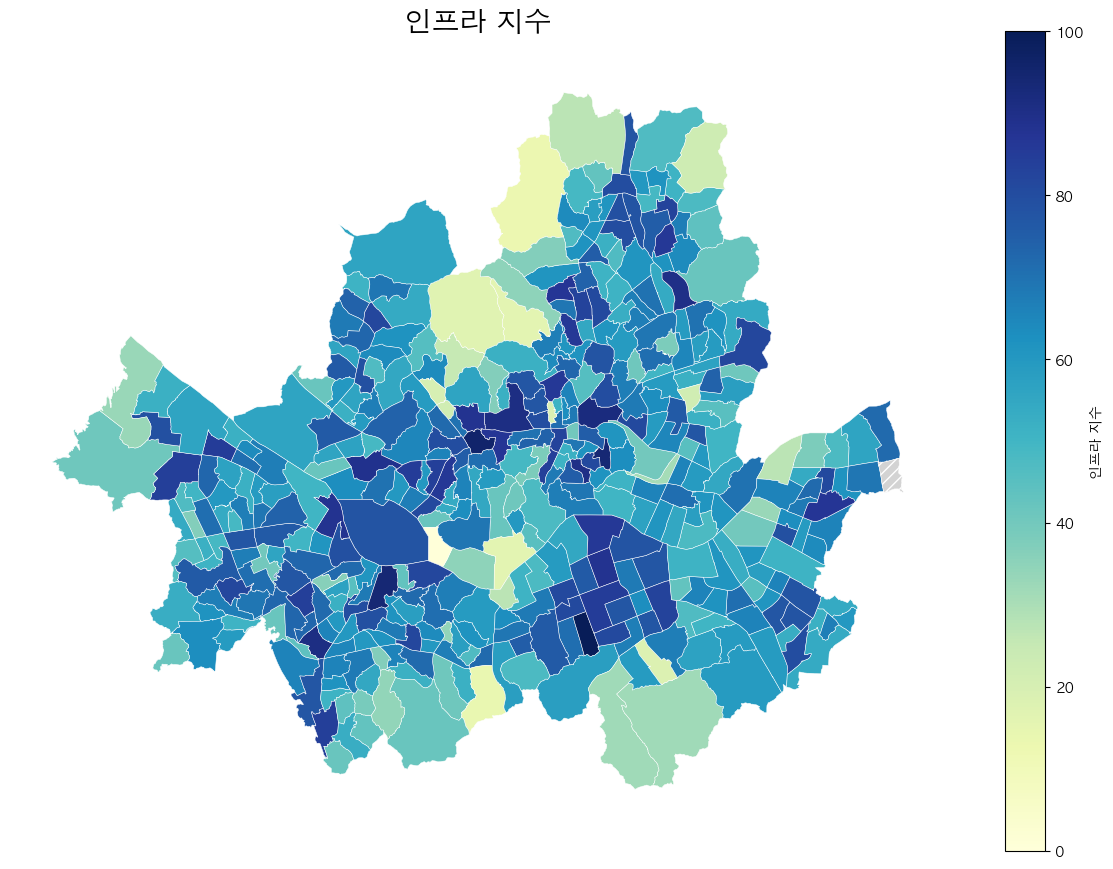


저장 완료: ./cleaned data/infra_final_v7/infra_score_map.png


In [32]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import platform

# =========================================================
# 0. 한글 폰트 설정
# =========================================================
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 1. 파일 경로
# =========================================================
score_path = "./cleaned data/infra_final_v7/infra_score.csv"
shp_path = "./data/bnd_dong_11_2025_2Q/bnd_dong_11_2025_2Q.shp"   # 필요하면 수정
save_path = "./cleaned data/infra_final_v7/infra_score_map.png"

# =========================================================
# 2. 데이터 불러오기
# =========================================================
df_score = pd.read_csv(score_path, encoding="utf-8-sig")
gdf = gpd.read_file(shp_path)

print("=== 점수 파일 컬럼 ===")
print(df_score.columns.tolist())

print("\n=== shp 파일 컬럼 ===")
print(gdf.columns.tolist())

# =========================================================
# 3. 컬럼명 지정
# =========================================================
score_code_col = "행정동코드"
score_col = "인프라지수"
shp_code_col = "ADM_CD"

# =========================================================
# 4. 코드 컬럼 형식 통일
# =========================================================
df_score[score_code_col] = (
    df_score[score_code_col]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

gdf[shp_code_col] = (
    gdf[shp_code_col]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(8)
)

# =========================================================
# 5. 병합
# =========================================================
gdf_merged = gdf.merge(
    df_score[[score_code_col, score_col]],
    left_on=shp_code_col,
    right_on=score_code_col,
    how="left"
)

print("\n=== 병합 결과 ===")
print("전체 행 수:", len(gdf_merged))
print("지수 결측 수:", gdf_merged[score_col].isna().sum())

# =========================================================
# 6. 시각화
# =========================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")

gdf_merged.plot(
    column=score_col,
    cmap="YlGnBu",
    linewidth=0.35,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "인프라 지수",
        "orientation": "vertical",
        "shrink": 0.7
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "결측"
    },
    ax=ax
)

ax.set_title("인프라 지수", fontsize=20, pad=20)
ax.axis("off")

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n저장 완료: {save_path}")